<a href="https://colab.research.google.com/github/pietroduke/GeoIdTree/blob/main/CVBMC_xception_none_154_10042026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KHỞI TẠO

**GG Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Unzip các tệp dataset cần thiết**

In [ ]:
!unzip /content/drive/MyDrive/dora_dataset/dataset_patches_filtered/VNUF-24082024-154.zip
!unzip /content/drive/MyDrive/dora_dataset/dataset_patches_filtered/VNUF-24082024-299.zip
!unzip /content/drive/MyDrive/dora_dataset/dataset_patches_filtered/VNUF-10082024-234.zip

Streaming output truncated to the last 5000 lines.
  inflating: VNUF-24082024-299/train/Chukrasia tabularis/340_patch4.png  
  inflating: VNUF-24082024-299/train/Chukrasia tabularis/340_patch5.png  
  inflating: VNUF-24082024-299/train/Chukrasia tabularis/340_patch6.png  
  inflating: VNUF-24082024-299/train/Chukrasia tabularis/340_patch7.png  
  inflating: VNUF-24082024-299/train/Chukrasia tabularis/340_patch8.png  
  inflating: VNUF-24082024-299/train/Chukrasia tabularis/340_patch9.png  
  inflating: VNUF-24082024-299/train/Chukrasia tabularis/394_patch1.png  
  inflating: VNUF-24082024-299/train/Chukrasia tabularis/394_patch2.png  
  inflating: VNUF-24082024-299/train/Chukrasia tabularis/394_patch3.png  
  inflating: VNUF-24082024-299/train/Chukrasia tabularis/394_patch4.png  
  inflating: VNUF-24082024-299/train/Chukrasia tabularis/394_patch5.png  
  inflating: VNUF-24082024-299/train/Chukrasia tabularis/396_patch1.png  
  inflating: VNUF-24082024-299/train/Chukrasia tabularis/396_

In [30]:
# import os

# root_dir = "/content/VNUF-24082024-154/train"

# image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')

# for subdir in os.listdir(root_dir):
#     subdir_path = os.path.join(root_dir, subdir)

#     if os.path.isdir(subdir_path):
#         count = sum(
#             1 for file in os.listdir(subdir_path)
#             if file.lower().endswith(image_extensions)
#         )
#         print(f"{subdir}: {count} ảnh")

In [31]:
# import numpy as np

# samples_per_class = [4225, 104, 2215, 1577, 2669, 963, 1668, 266, 167, 3039] # Ví dụ 110 lớp
# total_samples = sum(samples_per_class)

# # Cách 1: Nghịch đảo đơn giản
# weights = [total_samples / s for s in samples_per_class]

# # Cách 2: Chuẩn hóa để tổng hoặc trung bình bằng 1 (ổn định hơn)
# weights = np.array(weights)
# weights = weights / weights.sum() * 11 # Nhân với số lớp

# print(f"Bảng alpha nên set: {weights}")
# # Sau đó truyền vào: criterion = FocalLoss(alpha=weights, gamma=2)

**Khai báo thư viện**

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
import os
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score
import seaborn as sns
from typing import Dict, List, Optional, Callable
import json

In [33]:
# !rm -rf "/content/VNUF-24082024-154/train/Aphanamixis grandiflora"
# !rm -rf "/content/VNUF-24082024-154/test/Aphanamixis grandiflora"
# !rm -rf "/content/VNUF-24082024-154/val/Aphanamixis grandiflora"

# !rm -rf "/content/VNUF-24082024-299/train/Aphanamixis grandiflora"
# !rm -rf "/content/VNUF-24082024-299/test/Aphanamixis grandiflora"
# !rm -rf "/content/VNUF-24082024-299/val/Aphanamixis grandiflora"

# !rm -rf "/content/VNUF-10082024-234/train/Aphanamixis grandiflora"
# !rm -rf "/content/VNUF-10082024-234/test/Aphanamixis grandiflora"
# !rm -rf "/content/VNUF-10082024-234/val/Aphanamixis grandiflora"


# Hàm Loss


1.   Focal loss (xử lý mất cân bằng dữ liệu)
2.   Primary Loss (Triplet, Center)
3.   Secondary Loss (CORAL, Entropy, PNorm)



In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance"""
    def __init__(self, alpha=1, gamma=2, reduction='mean', num_classes=None):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction

        if isinstance(alpha, (list, np.ndarray)):
            self.alpha = torch.tensor(alpha, dtype=torch.float)
            if num_classes is not None and len(self.alpha) != num_classes:
                raise ValueError(f"Length of alpha tensor ({len(self.alpha)}) must match num_classes ({num_classes})")
        else:
            # If alpha is a scalar, it will be applied uniformly.
            self.alpha = alpha

    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)

        if isinstance(self.alpha, torch.Tensor):
            # Ensure alpha is on the same device as inputs
            if self.alpha.device != inputs.device:
                self.alpha = self.alpha.to(inputs.device)
            # Apply per-class alpha weighting by gathering relevant alpha for each target
            alpha_factor = self.alpha.gather(0, targets.view(-1))
        else:
            # Scalar alpha
            alpha_factor = self.alpha

        focal_loss = alpha_factor * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


class CombinedLoss(nn.Module):
    """Combined Loss: L_total = L_class"""
    def __init__(self, base_criterion):
        super(CombinedLoss, self).__init__()
        self.base_criterion = base_criterion

    def forward(self, logits, labels, features=None):
        # Base Classification Loss
        loss = self.base_criterion(logits, labels)
        return loss

# Định nghĩa các kỹ thuật khi training


1.   ES (Early Stopping) - Dừng sớm nếu val_loss không giảm (hoặc val_acc không tăng)
2.   ModelCheckpoint: Lấy model tại điểm có val_loss thấp nhất
3.  ReduceLROnPlateau: Hạ learning rate nếu sau số lượng n điểm mà val_loss không cải thiện



In [35]:
class EarlyStopping:
    """Early stopping callback"""
    def __init__(self, patience=7, min_delta=0, mode='max'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
        elif self.mode == 'max':
            if score < self.best_score + self.min_delta:
                self.counter += 1
                if self.counter >= self.patience:
                    self.early_stop = True
            else:
                self.best_score = score
                self.counter = 0
        else:  # mode == 'min'
            if score > self.best_score - self.min_delta:
                self.counter += 1
                if self.counter >= self.patience:
                    self.early_stop = True
            else:
                self.best_score = score
                self.counter = 0

        return self.early_stop

class ModelCheckpoint:
    """Model checkpoint callback"""
    def __init__(self, filepath, monitor='val_loss', mode='min', save_best_only=True):
        self.filepath = filepath
        self.monitor = monitor
        self.mode = mode
        self.save_best_only = save_best_only
        self.best_score = None

    def __call__(self, model, optimizer, epoch, metrics):
        score = metrics.get(self.monitor)

        if not self.save_best_only:
            self._save_model(model, optimizer, epoch, metrics)
            return False

        if self.best_score is None:
            self.best_score = score
            self._save_model(model, optimizer, epoch, metrics)
            return True

        improved = False
        if self.mode == 'max' and score > self.best_score:
            self.best_score = score
            self._save_model(model, optimizer, epoch, metrics)
            improved = True
        elif self.mode == 'min' and score < self.best_score:
            self.best_score = score
            self._save_model(model, optimizer, epoch, metrics)
            improved = True

        return improved

    def _save_model(self, model, optimizer, epoch, metrics):
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'metrics': metrics
        }, self.filepath)

class ReduceLROnPlateau:
    """Reduce learning rate when a metric has stopped improving"""
    def __init__(self, optimizer, monitor='val_loss', mode='min', factor=0.5,
                 patience=5, min_lr=1e-6, verbose=1):
        self.optimizer = optimizer
        self.monitor = monitor
        self.mode = mode
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr
        self.verbose = verbose

        self.best_score = None
        self.counter = 0
        self.current_lr = optimizer.param_groups[0]['lr']

    def __call__(self, metrics):
        score = metrics.get(self.monitor)

        if self.best_score is None:
            self.best_score = score
            return

        improved = False
        if self.mode == 'min':
            improved = score < self.best_score
        else:  # mode == 'max'
            improved = score > self.best_score

        if improved:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1

            if self.counter >= self.patience:
                old_lr = self.current_lr
                new_lr = max(old_lr * self.factor, self.min_lr)

                if new_lr < old_lr:
                    for param_group in self.optimizer.param_groups:
                        param_group['lr'] = new_lr
                    self.current_lr = new_lr
                    self.counter = 0

                    if self.verbose:
                        print(f"\n📉 ReduceLROnPlateau: reducing learning rate from {old_lr:.6f} to {new_lr:.6f}")

class LearningRateSchedulerCallback:
    """Learning rate scheduler callback with warmup"""
    def __init__(self, optimizer, warmup_epochs=5, min_lr=1e-6):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.min_lr = min_lr
        self.initial_lr = optimizer.param_groups[0]['lr']

    def on_epoch_end(self, epoch, scheduler):
        if epoch < self.warmup_epochs:
            # Warmup phase
            lr = self.initial_lr * (epoch + 1) / self.warmup_epochs
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = lr
        else:
            # Normal scheduling
            scheduler.step()

# Định nghĩa mô hình


1.   PlantModel: Lớp định nghĩa mô hình (gọi pretrain)
2.   ModelTrainer: Lớp gọi mô hình


In [36]:
!pip install imagecorruptions

In [37]:
import numpy as np
from PIL import Image
import random
from imagecorruptions import corrupt

class RandomGaussianNoiseImageCorruptions:
    def __init__(self, severity=1, p=0.5):
        """
        severity: Mức độ nhiễu từ 1 đến 5 (có thể là một số nguyên hoặc list các số nguyên)
        p: Xác suất áp dụng (0.0 đến 1.0)
        """
        self.severity = severity
        self.p = p

    def __call__(self, img):
        # Kiểm tra xác suất có áp dụng nhiễu hay không
        if random.random() < self.p:
            # Nếu severity là list/tuple, chọn ngẫu nhiên một mức độ
            sev = random.choice(self.severity) if isinstance(self.severity, (list, tuple)) else self.severity

            # 1. Chuyển PIL Image sang Numpy Array
            img_np = np.array(img)

            # 2. Áp dụng Gaussian Noise từ thư viện imagecorruptions
            img_corrupted_np = corrupt(img_np, corruption_name='gaussian_noise', severity=sev)

            # 3. Chuyển ngược lại Numpy Array thành PIL Image để đi tiếp vào Pipeline
            return Image.fromarray(img_corrupted_np)

        # Nếu không trúng xác suất, trả về ảnh gốc
        return img

In [38]:
class PlantModel(nn.Module):
    """Wrapper to return both features and logits"""
    def __init__(self, model_name, num_classes, pretrained=True):
        super(PlantModel, self).__init__()
        # Create model with num_classes=0 to get pooling output (features)
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        self.num_features = self.backbone.num_features
        self.classifier = nn.Linear(self.num_features, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        logits = self.classifier(features)
        return logits, features

class ModelTrainer:
    def __init__(self, train_dir, val_dir, test_dir, model_name='xception',
                 img_size=224, batch_size=32, lr=1e-4, epochs=50,
                 use_focal_loss=False, focal_alpha=1, focal_gamma=2,
                 primary_loss=None, secondary_loss=None,
                 lambda_primary=0.01, lambda_secondary=0.01,
                 device=None):

        self.train_dir = train_dir
        self.val_dir = val_dir
        self.test_dir = test_dir
        self.model_name = model_name
        self.img_size = img_size
        self.batch_size = batch_size
        self.lr = lr
        self.epochs = epochs
        self.use_focal_loss = use_focal_loss # New Loss Params
        self.focal_alpha = focal_alpha # Stored for setup
        self.focal_gamma = focal_gamma # Stored for setup
        # primary_loss and secondary_loss are no longer used for loss calculation directly
        # but kept for potential future use or configuration tracking
        self.primary_loss_name = primary_loss
        self.secondary_loss_name = secondary_loss
        self.lambda_primary = lambda_primary
        self.lambda_secondary = lambda_secondary

        self.device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # Training history
        self.train_losses = []
        self.val_losses = []
        self.train_accs = []
        self.val_accs = []
        self.val_precisions = []
        self.val_recalls = []
        self.val_f1s = []
        self.learning_rates = []

        # Callbacks
        self.callbacks = []

        self._setup_data()
        self._setup_model()
        self._setup_optimizer()

    def _setup_data(self):
        """Setup DataLoader"""
        train_transform = transforms.Compose([
            transforms.Resize((self.img_size, self.img_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.025),
            transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        test_transform = transforms.Compose([
            transforms.Resize((self.img_size, self.img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        self.train_dataset = datasets.ImageFolder(self.train_dir, transform=train_transform)
        self.val_dataset = datasets.ImageFolder(self.val_dir, transform=test_transform)
        self.test_dataset = datasets.ImageFolder(self.test_dir, transform=test_transform)

        self.train_loader = DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=4, pin_memory=True)
        self.val_loader = DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=4, pin_memory=True)
        self.test_loader = DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False, num_workers=4, pin_memory=True)

        self.num_classes = len(self.train_dataset.classes)
        self.class_names = self.train_dataset.classes
        print(f"Number of classes: {self.num_classes}")

    def _setup_model(self):
        """Setup model and combined loss function"""
        # Use Wrapper to get features
        self.model = PlantModel(self.model_name, self.num_classes)
        self.model = self.model.to(self.device)

        # Base Loss (only FocalLoss or CrossEntropyLoss now)
        if self.use_focal_loss:
            # Pass num_classes to FocalLoss to validate alpha tensor length
            base_loss = FocalLoss(alpha=self.focal_alpha, gamma=self.focal_gamma, num_classes=self.num_classes)
            if isinstance(self.focal_alpha, (list, np.ndarray, torch.Tensor)):
                print(f"Using Focal Loss with per-class alpha weights (gamma={self.focal_gamma})")
            else:
                print(f"Using Focal Loss (alpha={self.focal_alpha}, gamma={self.focal_gamma})")
        else:
            base_loss = nn.CrossEntropyLoss()
            print("Using CrossEntropy Loss")

        # Combined Loss only uses base_loss now
        self.criterion = CombinedLoss(
            base_loss
        )

        print(f"Model: {self.model_name}")
        print(f"Device: {self.device}")

    def _setup_optimizer(self):
        """Setup optimizer and scheduler"""
        # Collect parameters: model params + loss params (e.g., centers)
        params = list(self.model.parameters())

        self.optimizer = optim.AdamW(params, lr=self.lr, weight_decay=0.05)
        self.scheduler = optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=self.epochs)

    def add_callback(self, callback):
        self.callbacks.append(callback)

    def train_epoch(self):
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(self.train_loader, desc="Training")
        for images, labels in pbar:
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()
            # Model returns (logits, features)
            logits, features = self.model(images)

            # Criterion expects (logits, labels, features)
            loss = self.criterion(logits, labels, features)

            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            pbar.set_postfix({'Loss': f'{loss.item():.4f}', 'Acc': f'{100.*correct/total:.2f}%'})

        return running_loss / len(self.train_loader), 100. * correct / total

    def validate_epoch(self, data_loader, desc="Validation"):
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        all_predicted = []
        all_labels = []

        with torch.no_grad():
            pbar = tqdm(data_loader, desc=desc)
            for images, labels in pbar:
                images, labels = images.to(self.device), labels.to(self.device)

                logits, features = self.model(images)
                loss = self.criterion(logits, labels, features)

                running_loss += loss.item()
                _, predicted = torch.max(logits, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                all_predicted.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                pbar.set_postfix({'Loss': f'{loss.item():.4f}', 'Acc': f'{100.*correct/total:.2f}%'})

        epoch_loss = running_loss / len(data_loader)
        epoch_acc = 100. * correct / total
        precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_predicted, average='macro', zero_division=0)

        return epoch_loss, epoch_acc, precision*100, recall*100, f1*100, all_predicted, all_labels

    def train(self):
        print("Start training..."); print("="*50)
        for epoch in range(self.epochs):
            start_time = time.time()
            train_loss, train_acc = self.train_epoch()
            val_loss, val_acc, val_precision, val_recall, val_f1, _, _ = self.validate_epoch(self.val_loader, "Validation")
            current_lr = self.optimizer.param_groups[0]['lr']

            self.train_losses.append(train_loss); self.val_losses.append(val_loss)
            self.train_accs.append(train_acc); self.val_accs.append(val_acc)
            self.val_precisions.append(val_precision); self.val_recalls.append(val_recall)
            self.val_f1s.append(val_f1); self.learning_rates.append(current_lr)

            metrics = {'train_loss': train_loss, 'train_acc': train_acc, 'val_loss': val_loss, 'val_acc': val_acc,
                       'val_precision': val_precision, 'val_recall': val_recall, 'val_f1': val_f1}

            should_stop = False
            for callback in self.callbacks:
                if isinstance(callback, EarlyStopping):
                    if callback(val_loss):
                        print(f"🛑 Early stopping triggered at epoch {epoch+1}"); should_stop = True; break
                elif isinstance(callback, ModelCheckpoint):
                    if callback(self.model, self.optimizer, epoch, metrics):
                        print(f"💾 Saved best model at epoch {epoch+1}")
                elif isinstance(callback, ReduceLROnPlateau):
                    callback(metrics)
                elif isinstance(callback, LearningRateSchedulerCallback):
                    callback.on_epoch_end(epoch, self.scheduler)

            if not any(isinstance(cb, LearningRateSchedulerCallback) for cb in self.callbacks):
                self.scheduler.step()

            print(f"Epoch {epoch+1}/{self.epochs}")
            print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
            print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
            print(f"Val Precision: {val_precision:.2f}%, Val Recall: {val_recall:.2f}%, Val F1: {val_f1:.2f}%")
            print(f"LR: {current_lr:.6f}, Time: {time.time()-start_time:.2f}s")
            print("-" * 70)
            if should_stop: break

        return self._get_best_checkpoint_path()

    def _get_best_checkpoint_path(self):
        for callback in self.callbacks:
            if isinstance(callback, ModelCheckpoint): return callback.filepath
        return None

    def evaluate_on_test(self, model_path=None):
        if model_path and os.path.exists(model_path):
            print(f"Loading model from {model_path}")
            checkpoint = torch.load(model_path)
            self.model.load_state_dict(checkpoint['model_state_dict'])
        print("\n" + "="*70 + "\n🧪 EVALUATING ON TEST SET\n" + "="*70)
        test_loss, test_acc, test_precision, test_recall, test_f1, test_predicted, test_labels = self.validate_epoch(self.test_loader, "Testing")
        precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(test_labels, test_predicted, average=None, zero_division=0)
        print("\n🎯 DETAILED TEST RESULTS\n" + "="*70)
        print(f"Overall Accuracy: {test_acc:.2f}%"); print(f"Overall Precision (Macro): {test_precision:.2f}%")
        print(f"Overall Recall (Macro): {test_recall:.2f}%"); print(f"Overall F1-Score (Macro): {test_f1:.2f}%")
        print("="*70)
        print("\n📊 PER-CLASS METRICS:"); print("-"*70)
        print(f"{'Class':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}"); print("-"*70)
        for i, class_name in enumerate(self.class_names):
            print(f"{class_name:<20} {precision_per_class[i]*100:<11.2f}% {recall_per_class[i]*100:<11.2f}% {f1_per_class[i]*100:<11.2f}% {support[i]:<10}")
        print("-"*70)
        print("\n📈 CLASSIFICATION REPORT:")
        print(classification_report(test_labels, test_predicted, target_names=self.class_names, digits=4))
        metrics_summary = {'test_accuracy': float(test_acc), 'test_precision': float(test_precision),
                           'test_recall': float(test_recall), 'test_f1_score': float(test_f1),
                           'per_class_metrics': {class_name: {'precision': float(precision_per_class[i]*100),
                                                              'recall': float(recall_per_class[i]*100),
                                                              'f1_score': float(f1_per_class[i]*100),
                                                              'support': int(support[i])} for i, class_name in enumerate(self.class_names)}}
        with open('test_metrics.json', 'w') as f: json.dump(metrics_summary, f, indent=4)
        print("\n💾 Test metrics saved to test_metrics.json")
        return test_predicted, test_labels, metrics_summary

# Vẽ biểu đồ

In [39]:
def plot_training_history(trainer_or_history, save_path='training_history.png'):
    """Plot training history

    Args:
        trainer_or_history: Can be either a trainer object or path to history JSON file
        save_path: Path to save the plot
    """
    # If it's a string (file path), load the history
    if isinstance(trainer_or_history, str):
        with open(trainer_or_history, 'r') as f:
            history = json.load(f)
        train_losses = history['train_losses']
        val_losses = history['val_losses']
        train_accs = history['train_accs']
        val_accs = history['val_accs']
        val_precisions = history['val_precisions']
        val_recalls = history['val_recalls']
        val_f1s = history['val_f1s']
        learning_rates = history['learning_rates']
    else:
        # If it's a trainer object
        train_losses = trainer_or_history.train_losses
        val_losses = trainer_or_history.val_losses
        train_accs = trainer_or_history.train_accs
        val_accs = trainer_or_history.val_accs
        val_precisions = trainer_or_history.val_precisions
        val_recalls = trainer_or_history.val_recalls
        val_f1s = trainer_or_history.val_f1s
        learning_rates = trainer_or_history.learning_rates

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 12))

    # Loss plot
    ax1.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
    ax1.plot(val_losses, label='Val Loss', color='red', linewidth=2)
    ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy plot
    ax2.plot(train_accs, label='Train Acc', color='blue', linewidth=2)
    ax2.plot(val_accs, label='Val Acc', color='red', linewidth=2)
    ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Precision and Recall plot
    ax3.plot(val_precisions, label='Val Precision', color='green', linewidth=2)
    ax3.plot(val_recalls, label='Val Recall', color='orange', linewidth=2)
    ax3.set_title('Validation Precision and Recall', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Percentage (%)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # F1-Score and Learning Rate plot
    ax4_twin = ax4.twinx()
    ax4.plot(val_f1s, label='Val F1-Score', color='purple', linewidth=2)
    ax4_twin.plot(learning_rates, label='Learning Rate', color='brown',
                  linewidth=2, linestyle='--')
    ax4.set_title('Validation F1-Score and Learning Rate', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('F1-Score (%)', color='purple')
    ax4_twin.set_ylabel('Learning Rate', color='brown')
    ax4.legend(loc='upper left')
    ax4_twin.legend(loc='upper right')
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"📊 Training history plot saved to {save_path}")
    plt.show()


def plot_confusion_matrix(test_labels, test_predicted, class_names,
                         save_path='confusion_matrix.png',
                         scientific_names=None, normalize_per_row=True):
    """Plot confusion matrix with smart color normalization

    Args:
        test_labels: True labels
        test_predicted: Predicted labels
        class_names: Original class names (folder names)
        save_path: Path to save the plot
        scientific_names: List of scientific names to display (if None, use class_names)
        normalize_per_row: If True, normalize colors by row percentage (better for imbalanced data)
    """
    cm = confusion_matrix(test_labels, test_predicted)

    # Use scientific names if provided, otherwise use original class names
    display_names = scientific_names if scientific_names is not None else class_names

    # Create figure
    fig, ax = plt.subplots(figsize=(16, 14))

    if normalize_per_row:
        # Calculate percentage for each row (for coloring only)
        cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm_percent = np.nan_to_num(cm_percent)  # Handle division by zero

        # Use percentage values for coloring (0-1 scale)
        # But annotate with actual counts
        sns.heatmap(cm_percent,
                    annot=cm,  # Show counts
                    fmt='d',   # Integer format
                    cmap='Blues',
                    xticklabels=display_names,
                    yticklabels=display_names,
                    cbar_kws={'label': 'Percentage (color scale)'},
                    vmin=0,
                    vmax=1,
                    ax=ax)

        title = 'Confusion Matrix (colors = row percentages, values = counts)'
    else:
        # Standard confusion matrix without normalization
        sns.heatmap(cm,
                    annot=True,
                    fmt='d',
                    cmap='Blues',
                    xticklabels=display_names,
                    yticklabels=display_names,
                    cbar_kws={'label': 'Count'},
                    ax=ax)

        title = 'Confusion Matrix (Counts)'

    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"📊 Confusion matrix saved to {save_path}")
    plt.show()

# Thiết lập đường dẫn và định nghĩa hàm huấn luyện và chạy quá trình huấn luyện

In [40]:
# Constants
# TRAIN_DIR = "/content/vnuf_classification/train"
# VAL_DIR = "/content/vnuf_classification/val"
# TEST_DIR = "/content/vnuf_classification/test"

TRAIN_DIR = "/content/VNUF-24082024-154/train"
VAL_DIR = "/content/VNUF-24082024-154/val"
TEST_DIR = "/content/VNUF-24082024-154/test"

DEFAULT_CONFIG = {
    'model_name': 'xception',
    'img_size': 224,
    'batch_size': 64,
    'lr': 1e-5,
    'epochs': 50,
    'use_focal_loss': True,
    'focal_alpha': [0.11306636, 4.5933208, 0.21566834, 0.30292033, 0.1789829, 0.49605957, 0.2863941, 1.79588482, 2.86051115, 0.15719163],
    'focal_gamma': 2.0,
    # New loss components
    'primary_loss': None,   # Options: 'triplet', 'center', 'triplet+center' or None
    'secondary_loss': None, # Options: 'entropy', 'pnorm', 'coral', 'mmd' or None
    'lambda_primary': 0.01,
    'lambda_secondary': 0.01
}

In [41]:
def run_training(config=DEFAULT_CONFIG):
    """Run training process"""
    for path, name in [(TRAIN_DIR, "train"), (VAL_DIR, "validation"), (TEST_DIR, "test")]:
        if not os.path.exists(path):
            print(f"❌ Cannot find {name} directory: {path}")
            return None

    print("🚀 Starting Training Process with Advanced Losses...")

    trainer = ModelTrainer(
        train_dir=TRAIN_DIR,
        val_dir=VAL_DIR,
        test_dir=TEST_DIR,
        **config
    )

    early_stopping = EarlyStopping(patience=10, min_delta=0.001, mode='min')
    checkpoint_name = f'NONE_VNUF154_best_{config["model_name"]}.pth'
    model_checkpoint = ModelCheckpoint(filepath=checkpoint_name, monitor='val_loss', mode='min', save_best_only=True)
    reduce_lr = ReduceLROnPlateau(optimizer=trainer.optimizer, monitor='val_loss', mode='min', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

    trainer.add_callback(early_stopping)
    trainer.add_callback(model_checkpoint)
    trainer.add_callback(reduce_lr)

    best_model_path = trainer.train()
    if best_model_path:
        plot_training_history(trainer, save_path='training_history.png')

    return best_model_path

Running Training Step...
🚀 Starting Training Process with Advanced Losses...
Number of classes: 10


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth
Using Focal Loss with per-class alpha weights (gamma=2.0)
Model: xception
Device: cuda
Start training...


Validation: 100%|██████████| 26/26 [00:02<00:00, 12.27it/s, Loss=0.0668, Acc=76.51%]


💾 Saved best model at epoch 1
Epoch 1/50
Train Loss: 0.3730, Train Acc: 58.66%
Val Loss: 0.2876, Val Acc: 76.51%
Val Precision: 66.21%, Val Recall: 74.33%, Val F1: 66.43%
LR: 0.000010, Time: 65.00s
----------------------------------------------------------------------


...

Epoch 13/50
Train Loss: 0.0140, Train Acc: 93.81%
Val Loss: 0.1312, Val Acc: 84.48%
Val Precision: 81.23%, Val Recall: 79.47%, Val F1: 79.14%
LR: 0.000002, Time: 61.75s
----------------------------------------------------------------------


Validation: 100%|██████████| 26/26 [00:02<00:00, 12.51it/s, Loss=0.0003, Acc=84.54%]



📉 ReduceLROnPlateau: reducing learning rate from 0.000003 to 0.000001
Epoch 14/50
Train Loss: 0.0137, Train Acc: 93.95%
Val Loss: 0.1261, Val Acc: 84.54%
Val Precision: 81.28%, Val Recall: 79.87%, Val F1: 79.26%
LR: 0.000002, Time: 62.33s
----------------------------------------------------------------------


Validation: 100%|██████████| 26/26 [00:02<00:00, 12.36it/s, Loss=0.0006, Acc=84.36%]


🛑 Early stopping triggered at epoch 15
Epoch 15/50
Train Loss: 0.0137, Train Acc: 94.09%
Val Loss: 0.1343, Val Acc: 84.36%
Val Precision: 81.84%, Val Recall: 79.28%, Val F1: 79.28%
LR: 0.000001, Time: 61.84s
----------------------------------------------------------------------
📊 Training history plot saved to training_history.png


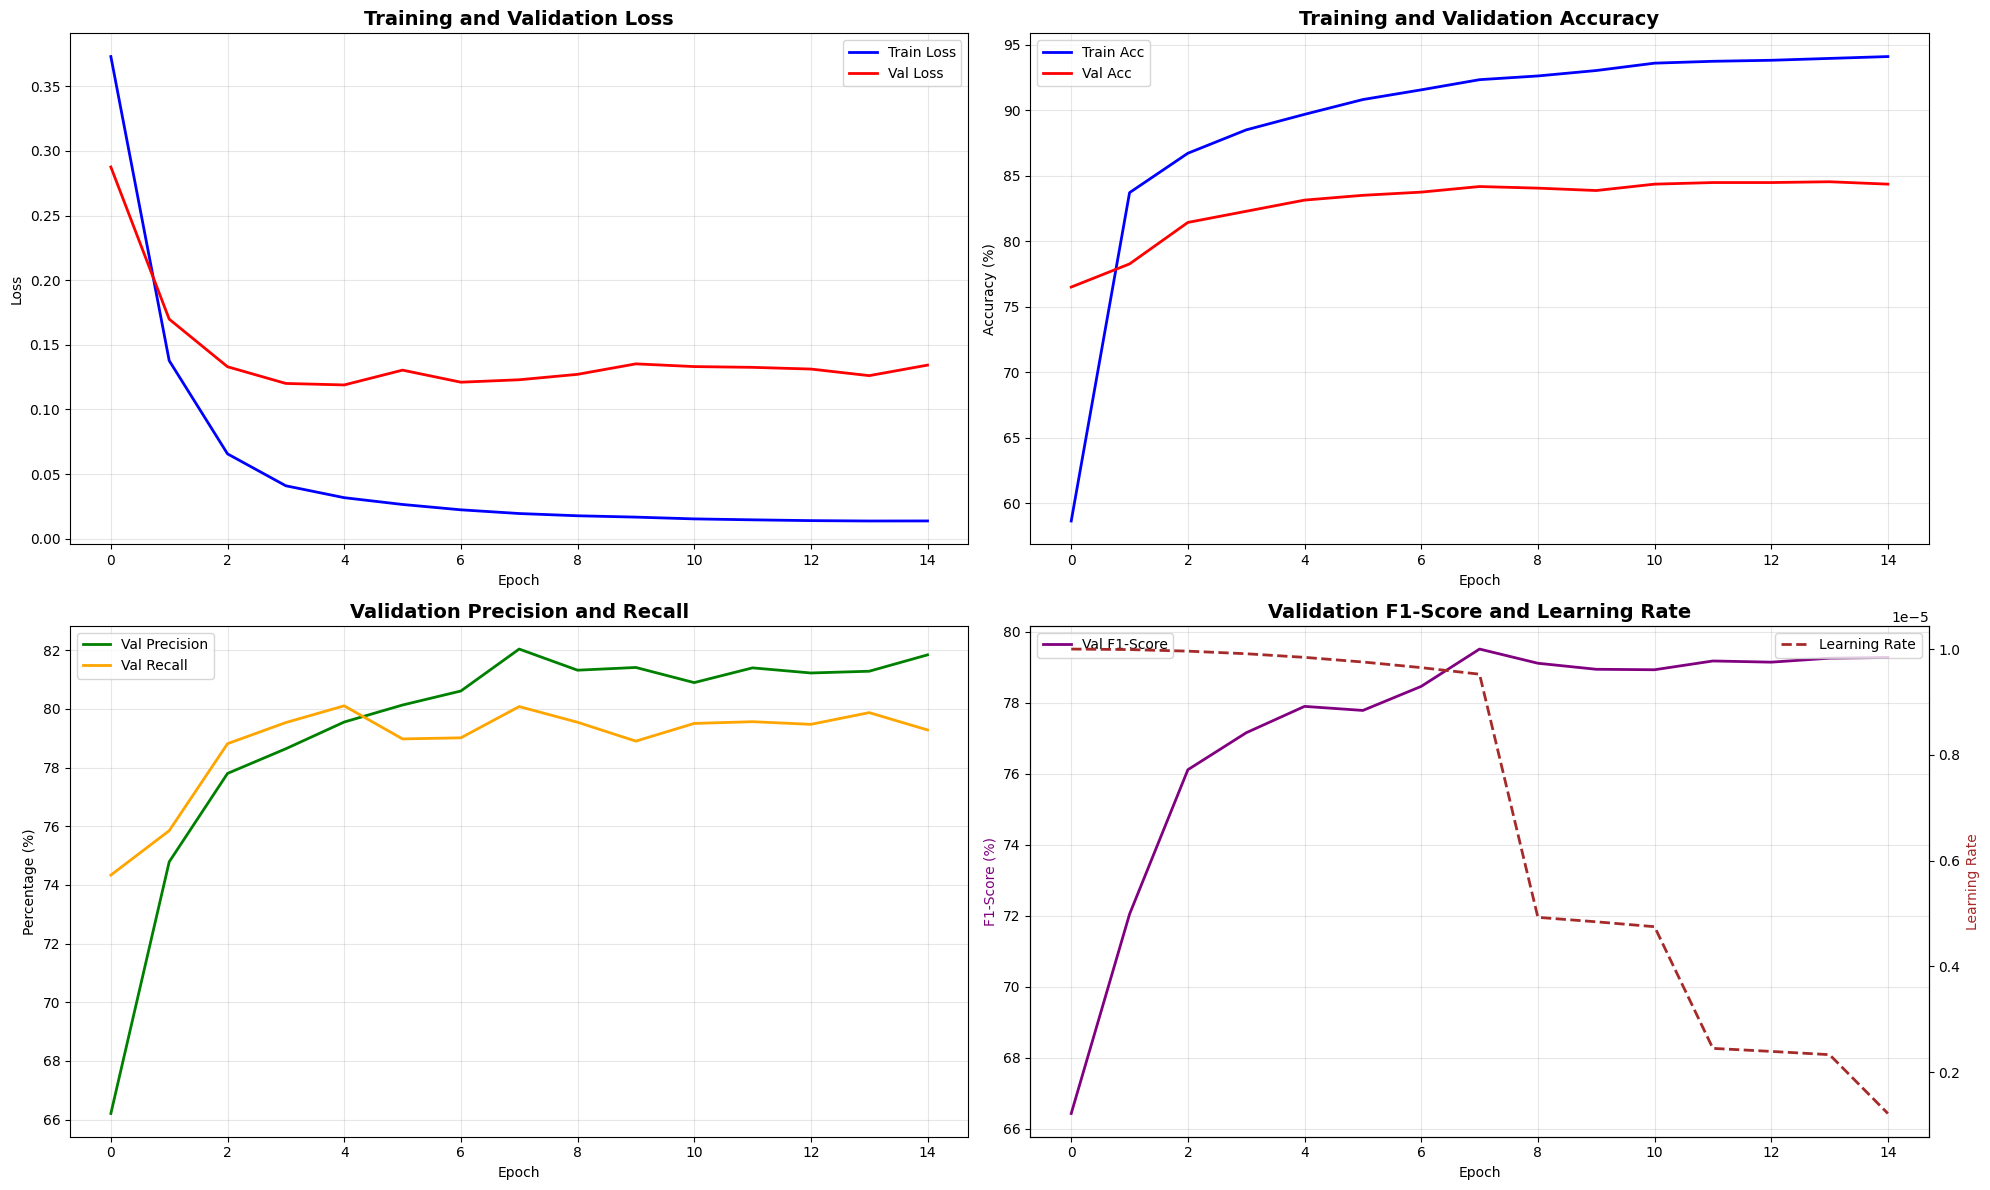

In [42]:
# 1. Cell này dùng để Train (Comment lại nếu không muốn chạy lại)
print("Running Training Step...")
best_model_path = run_training()

In [43]:
vit_models = timm.list_models('*vit_base*')
print(vit_models)

['convit_base', 'crossvit_base_240', 'davit_base', 'davit_base_fl', 'flexivit_base', 'gcvit_base', 'maxvit_base_tf_224', 'maxvit_base_tf_384', 'maxvit_base_tf_512', 'naflexvit_base_patch16_gap', 'naflexvit_base_patch16_map', 'naflexvit_base_patch16_par_gap', 'naflexvit_base_patch16_parfac_gap', 'naflexvit_base_patch16_siglip', 'nextvit_base', 'samvit_base_patch16', 'samvit_base_patch16_224', 'vit_base_mci_224', 'vit_base_patch8_224', 'vit_base_patch14_dinov2', 'vit_base_patch14_reg4_dinov2', 'vit_base_patch16_18x2_224', 'vit_base_patch16_224', 'vit_base_patch16_224_miil', 'vit_base_patch16_384', 'vit_base_patch16_clip_224', 'vit_base_patch16_clip_384', 'vit_base_patch16_clip_quickgelu_224', 'vit_base_patch16_dinov3', 'vit_base_patch16_dinov3_qkvb', 'vit_base_patch16_gap_224', 'vit_base_patch16_plus_240', 'vit_base_patch16_plus_clip_240', 'vit_base_patch16_reg4_gap_256', 'vit_base_patch16_rope_224', 'vit_base_patch16_rope_ape_224', 'vit_base_patch16_rope_mixed_224', 'vit_base_patch16_ro

# **KIỂM TRA VỚI DỮ LIỆU CỦA 4 TỆP**

**0) VỚI TỆP MẶC ĐỊNH**

In [44]:
def run_testing(model_path, config=DEFAULT_CONFIG):
    """Run testing process separately"""
    print(f"🚀 Starting Testing Process using model: {model_path}...")

    if not os.path.exists(model_path):
        print(f"❌ Model path not found: {model_path}")
        return

    # Initialize trainer (for dataloaders and model structure)
    trainer = ModelTrainer(
        train_dir=TRAIN_DIR,
        val_dir=VAL_DIR,
        test_dir=TEST_DIR,
        **config
    )

    # Evaluate on test set
    test_predicted, test_labels, metrics = trainer.evaluate_on_test(model_path)

    # Plot confusion matrix with scientific names
    plot_confusion_matrix(
        test_labels,
        test_predicted,
        trainer.class_names,
        save_path='test_confusion_matrix.png',
        # scientific_names=SCIENTIFIC_NAMES,
        normalize_per_row=True
    )

    # Global scale confusion matrix
    plot_confusion_matrix(
        test_labels,
        test_predicted,
        trainer.class_names,
        save_path='test_confusion_matrix_global.png',
        # scientific_names=SCIENTIFIC_NAMES,
        normalize_per_row=False
    )

    # Print final results
    print(f"\n🎉 FINAL TEST RESULTS:")
    print(f"   Accuracy: {metrics['test_accuracy']:.2f}%")
    print(f"   Precision: {metrics['test_precision']:.2f}%")
    print(f"   Recall: {metrics['test_recall']:.2f}%")
    print(f"   F1-Score: {metrics['test_f1_score']:.2f}%")

    return metrics

Running Testing Step...
🚀 Starting Testing Process using model: NONE_VNUF154_best_xception.pth...
Number of classes: 10


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Using Focal Loss with per-class alpha weights (gamma=2.0)
Model: xception
Device: cuda
Loading model from NONE_VNUF154_best_xception.pth

🧪 EVALUATING ON TEST SET


Testing: 100%|██████████| 13/13 [00:01<00:00, 11.01it/s, Loss=0.0007, Acc=81.60%]



🎯 DETAILED TEST RESULTS
Overall Accuracy: 81.60%
Overall Precision (Macro): 79.69%
Overall Recall (Macro): 75.00%
Overall F1-Score (Macro): 75.28%

📊 PER-CLASS METRICS:
----------------------------------------------------------------------
Class                Precision    Recall       F1-Score     Support   
----------------------------------------------------------------------
Acacia auriculiformis 93.62      % 94.96      % 94.29      % 139       
Alstonia scholaris   100.00     % 75.00      % 85.71      % 8         
Aphanamixis grandifolia 87.18      % 78.16      % 82.42      % 87        
Chukrasia tabularis  73.04      % 88.42      % 80.00      % 95        
Cinnamomum parthenoxylon 57.89      % 33.33      % 42.31      % 66        
Delonix regia        93.55      % 100.00     % 96.67      % 29        
Dracontomelon dao    51.18      % 95.59      % 66.67      % 68        
Ficus benghalensis   57.14      % 23.53      % 33.33      % 17        
Lagerstroemia speciosa 83.33      % 73.17

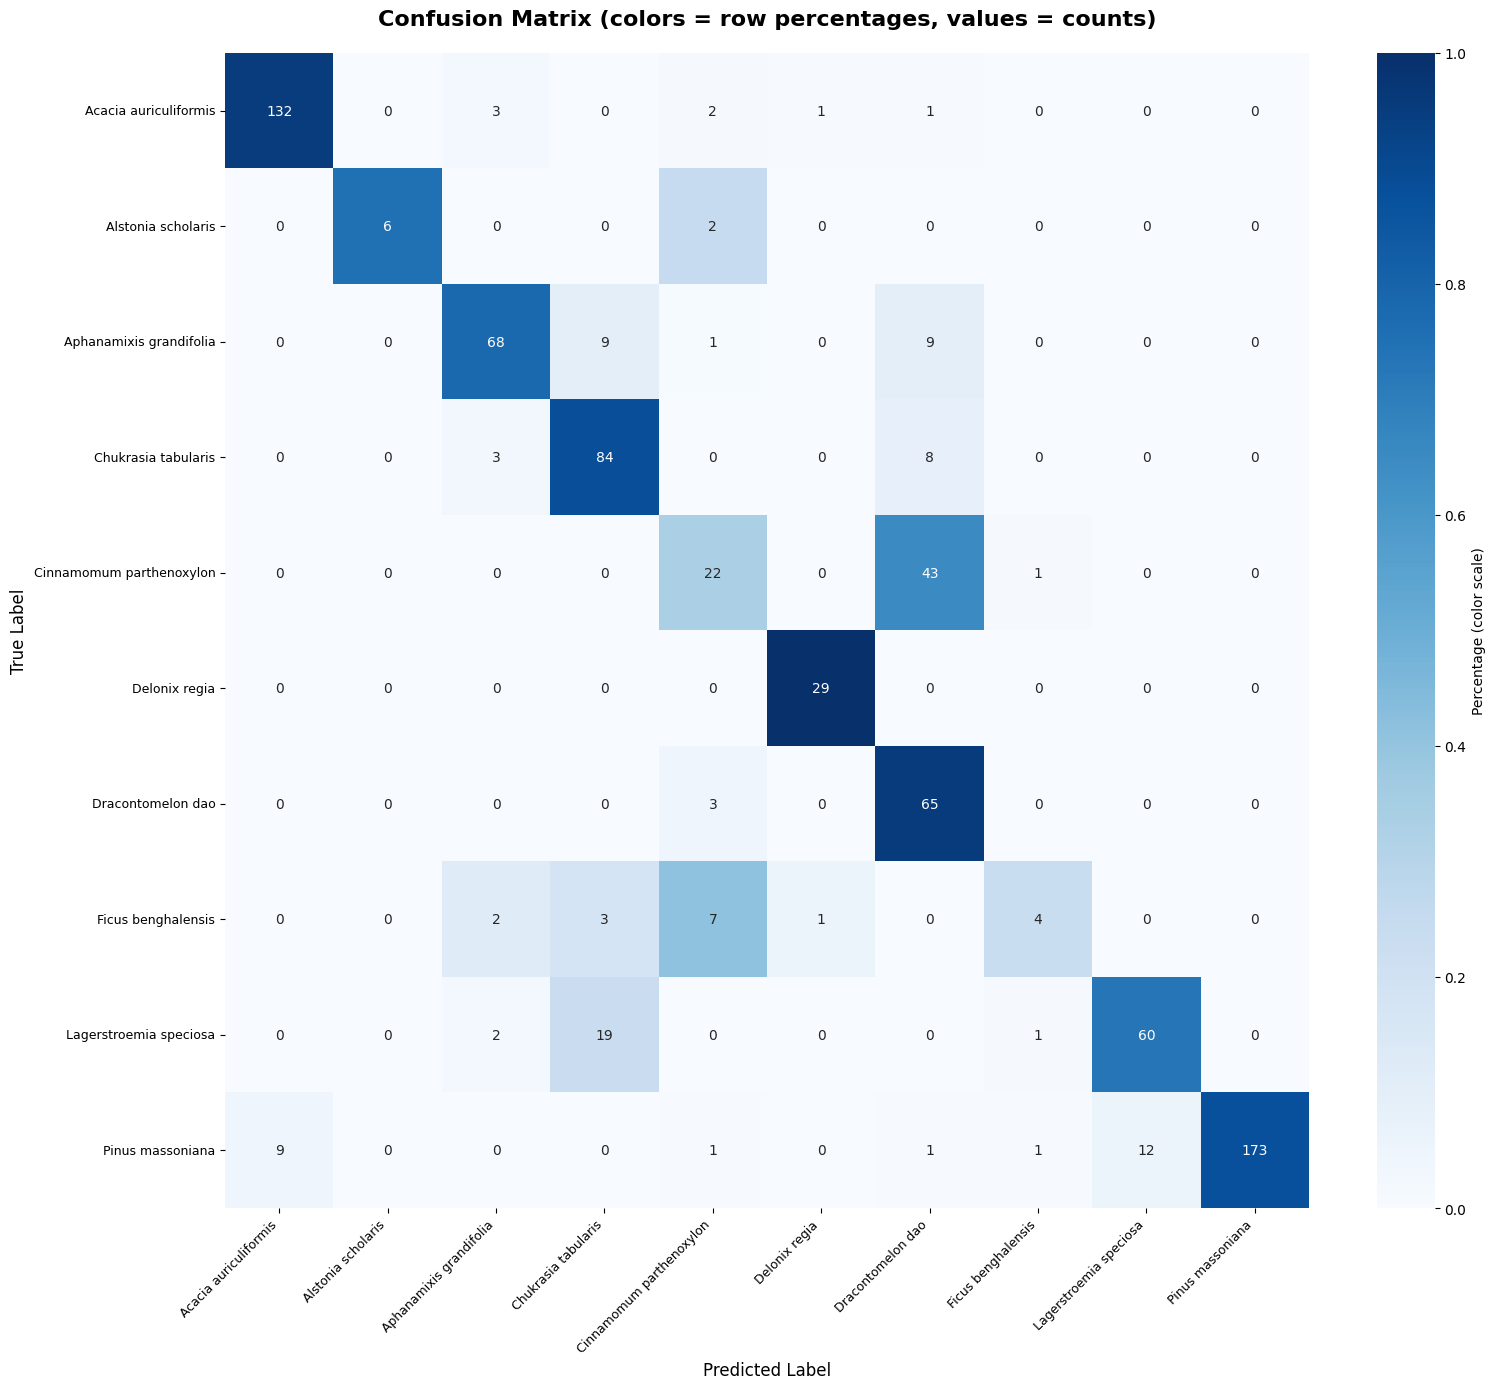

📊 Confusion matrix saved to test_confusion_matrix_global.png


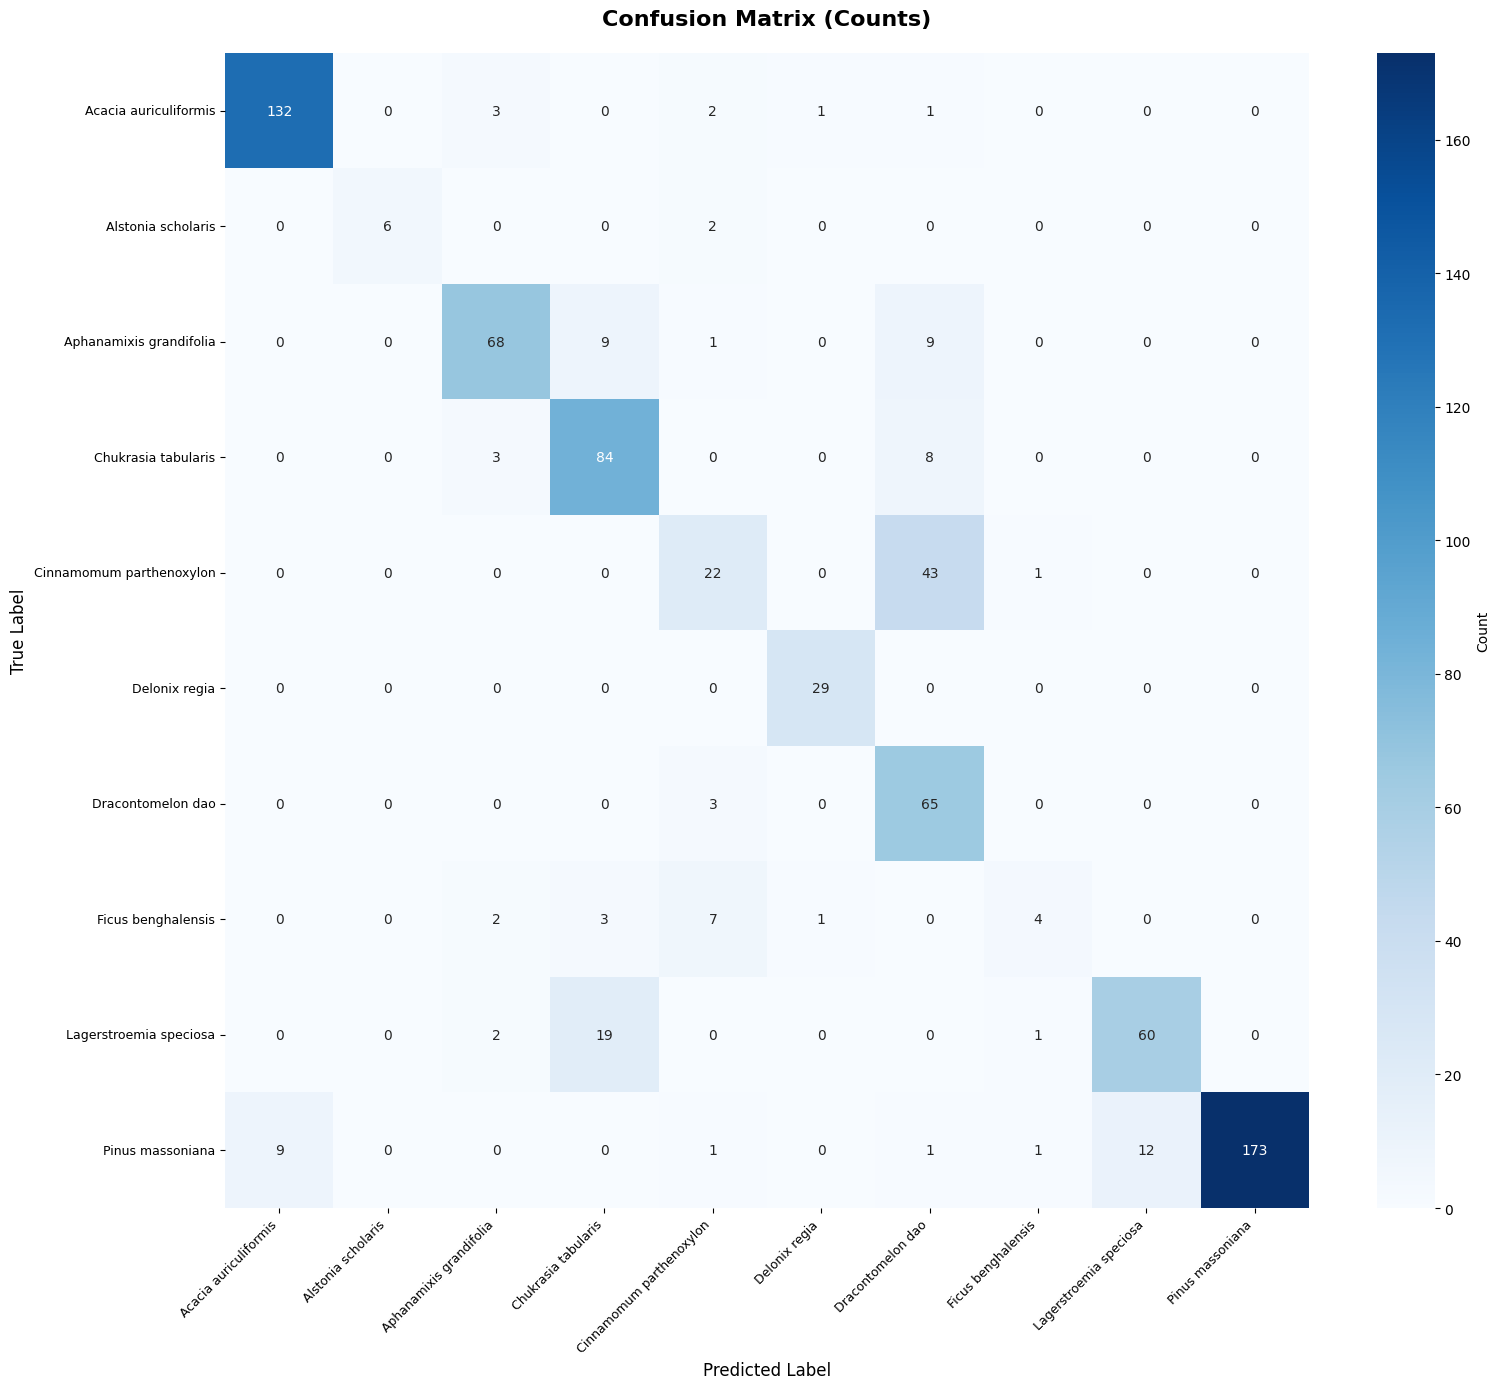


🎉 FINAL TEST RESULTS:
   Accuracy: 81.60%
   Precision: 79.69%
   Recall: 75.00%
   F1-Score: 75.28%


{'test_accuracy': 81.5989847715736,
 'test_precision': 79.6940403494227,
 'test_recall': 74.99849719315098,
 'test_f1_score': 75.28341928341928,
 'per_class_metrics': {'Acacia auriculiformis': {'precision': 93.61702127659575,
   'recall': 94.96402877697841,
   'f1_score': 94.28571428571428,
   'support': 139},
  'Alstonia scholaris': {'precision': 100.0,
   'recall': 75.0,
   'f1_score': 85.71428571428571,
   'support': 8},
  'Aphanamixis grandifolia': {'precision': 87.17948717948718,
   'recall': 78.16091954022988,
   'f1_score': 82.42424242424242,
   'support': 87},
  'Chukrasia tabularis': {'precision': 73.04347826086956,
   'recall': 88.42105263157895,
   'f1_score': 80.0,
   'support': 95},
  'Cinnamomum parthenoxylon': {'precision': 57.89473684210527,
   'recall': 33.33333333333333,
   'f1_score': 42.30769230769231,
   'support': 66},
  'Delonix regia': {'precision': 93.54838709677419,
   'recall': 100.0,
   'f1_score': 96.66666666666667,
   'support': 29},
  'Dracontomelon dao':

In [45]:
TEST_DIR = "/content/VNUF-24082024-154/test"

# 2. Cell này dùng để Test riêng biệt
print("Running Testing Step...")

# Sử dụng model đã lưu từ lần train trước
model_path = f"NONE_VNUF154_best_{DEFAULT_CONFIG['model_name']}.pth"
# model_path = "/content/drive/MyDrive/cvbmc/model_chkpoint/NONE_VNUF154_best_xception.pth"

# Chạy test
run_testing(model_path)

### Dự đoán từng ảnh trong một thư mục

In [47]:
import os
from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

def predict_images_in_folder(trainer_instance, folder_path, images_per_row=3):
    """
    Predicts the class for each image in a given folder using the provided trainer's model and transformations.
    Displays images in a grid, along with class probabilities and predicted class name for each.
    """
    model = trainer_instance.model
    class_names = trainer_instance.class_names
    device = trainer_instance.device

    transform = transforms.Compose([
        transforms.Resize((trainer_instance.img_size, trainer_instance.img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    if not os.path.exists(folder_path):
        print(f"❌ Folder not found: {folder_path}")
        return

    model.eval() # Set model to evaluation mode

    print(f"📸 Starting prediction for images in: {folder_path}")
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if not image_files:
        print("No image files found in the specified folder.")
        return

    sorted_image_files = sorted(image_files)
    num_images = len(sorted_image_files)

    for i in range(0, num_images, images_per_row):
        batch_filenames = sorted_image_files[i : i + images_per_row]
        batch_display_images = []
        batch_predictions = [] # Store (probabilities, predicted_class_name, filename) for each image in batch

        # Process each image in the current batch
        for filename in batch_filenames:
            image_path = os.path.join(folder_path, filename)
            image = Image.open(image_path).convert('RGB') # Changed from RGBA to RGB
            batch_display_images.append(image)

            input_tensor = transform(image).unsqueeze(0).to(device)

            with torch.no_grad():
                logits, _ = model(input_tensor)
                probabilities = F.softmax(logits, dim=1)[0]

            predicted_idx = torch.argmax(probabilities).item()
            predicted_class_name = class_names[predicted_idx]

            batch_predictions.append({'filename': filename, 'probabilities': probabilities, 'predicted_class_name': predicted_class_name})

        # Create a figure with 2 rows for images and their text predictions
        fig, axes = plt.subplots(2, len(batch_display_images), figsize=(len(batch_display_images) * 4, 8))
        if len(batch_display_images) == 1:
            axes = np.array([axes]).T # Ensure axes is 2D for consistent indexing if only one image

        for idx, prediction_data in enumerate(batch_predictions):
            # Plot image
            axes[0, idx].imshow(batch_display_images[idx])
            axes[0, idx].set_title(f"{prediction_data['filename']}", fontsize=10)
            axes[0, idx].axis('off')

            # Prepare text for probabilities and predicted class
            prob_text = "♥ Class Probabilities:\n"
            prob_dict = {class_names[j]: prob.item() for j, prob in enumerate(prediction_data['probabilities'])}
            sorted_probs = sorted(prob_dict.items(), key=lambda item: item[1], reverse=True)
            for class_name_prob, prob_value in sorted_probs:
                prob_text += f"  {class_name_prob}: {prob_value:.4f}\n"
            prob_text += f"♥ Predicted Class: {prediction_data['predicted_class_name']}"

            # Display text in the subplot below the image
            axes[1, idx].text(0.05, 0.95, prob_text, transform=axes[1, idx].transAxes,
                             verticalalignment='top', fontsize=11, wrap=True)
            axes[1, idx].axis('off') # Hide axes for text subplot

        plt.tight_layout()
        plt.show()

    print("✨ Quá trình dự đoán hoàn tất.")

In [48]:
# !unzip /content/drive/MyDrive/dora_dataset/dataset_rectangle/VNUF-24082024-299.zip

In [49]:
# --- Cấu hình và chạy dự đoán từng ảnh ---

# **THAY ĐỔI ĐƯỜNG DẪN THƯ MỤC CẦN DỰ ĐOÁN TẠI ĐÂY**
# Ví dụ: Sử dụng một thư mục con từ bộ dữ liệu thử nghiệm của bạn.
PREDICT_FOLDER_PATH = "/content/VNUF-24082024-154/test/Ficus benghalensis"

# Tên file model đã được lưu sau quá trình huấn luyện
model_to_load = "/content/drive/MyDrive/cvbmc/model_chkpoint/NONE_VNUF154_best_xception.pth"

print("🚀 Bắt đầu quá trình dự đoán ảnh đơn lẻ...")

# 1. Khởi tạo một thể hiện của ModelTrainer.
#    Chúng ta cần nó để thiết lập cấu trúc mô hình, biến đổi ảnh và lấy tên các lớp.
#    Các đường dẫn thư mục `train_dir`, `val_dir`, `test_dir` cần hợp lệ để `ImageFolder` có thể đọc được tên các lớp.
temp_trainer = ModelTrainer(
    train_dir=TRAIN_DIR,
    val_dir=VAL_DIR,
    test_dir=TEST_DIR,
    **DEFAULT_CONFIG
)

# 2. Load trọng số của mô hình tốt nhất đã được huấn luyện
if os.path.exists(model_to_load):
    print(f"Đang tải trọng số mô hình từ {model_to_load}")
    # Đảm bảo model được load lên cùng device với trainer
    checkpoint = torch.load(model_to_load, map_location=temp_trainer.device)
    temp_trainer.model.load_state_dict(checkpoint['model_state_dict'])
    print("Tải mô hình thành công.")

    # 3. Chạy dự đoán trên thư mục đã chỉ định
    predict_images_in_folder(temp_trainer, PREDICT_FOLDER_PATH)
else:
    print(f"❌ Không tìm thấy file checkpoint mô hình tại {model_to_load}. "
          "Vui lòng đảm bảo mô hình đã được huấn luyện và lưu đúng cách.")

print("Hoàn thành.")

🚀 Bắt đầu quá trình dự đoán ảnh đơn lẻ...
Number of classes: 10


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Using Focal Loss with per-class alpha weights (gamma=2.0)
Model: xception
Device: cuda
❌ Không tìm thấy file checkpoint mô hình tại /content/drive/MyDrive/cvbmc/model_chkpoint/NONE_VNUF154_best_xception.pth. Vui lòng đảm bảo mô hình đã được huấn luyện và lưu đúng cách.
Hoàn thành.


In [50]:
# !rm -rf /content/vnuf_classification/test/background

Running Testing Step...
🚀 Starting Testing Process using model: NONE_VNUF154_best_xception.pth...
Number of classes: 10
Using Focal Loss with per-class alpha weights (gamma=2.0)
Model: xception
Device: cuda
Loading model from NONE_VNUF154_best_xception.pth

🧪 EVALUATING ON TEST SET


Testing: 100%|██████████| 2/2 [00:00<00:00,  3.59it/s, Loss=0.5205, Acc=76.58%]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c


🎯 DETAILED TEST RESULTS
Overall Accuracy: 76.58%
Overall Precision (Macro): 61.21%
Overall Recall (Macro): 63.23%
Overall F1-Score (Macro): 61.89%

📊 PER-CLASS METRICS:
----------------------------------------------------------------------
Class                Precision    Recall       F1-Score     Support   
----------------------------------------------------------------------
Acacia auriculiformis 91.67      % 91.67      % 91.67      % 12        
Alstonia scholaris   50.00      % 50.00      % 50.00      % 2         
Aphanamixis grandifolia 60.00      % 81.82      % 69.23      % 11        
Chukrasia tabularis  80.00      % 76.19      % 78.05      % 21        
Cinnamomum parthenoxylon 20.00      % 12.50      % 15.38      % 8         
Delonix regia        100.00     % 100.00     % 100.00     % 6         
Dracontomelon dao    50.00      % 62.50      % 55.56      % 8         
Ficus benghalensis   0.00       % 0.00       % 0.00       % 1         
Lagerstroemia speciosa 66.67      % 66.67

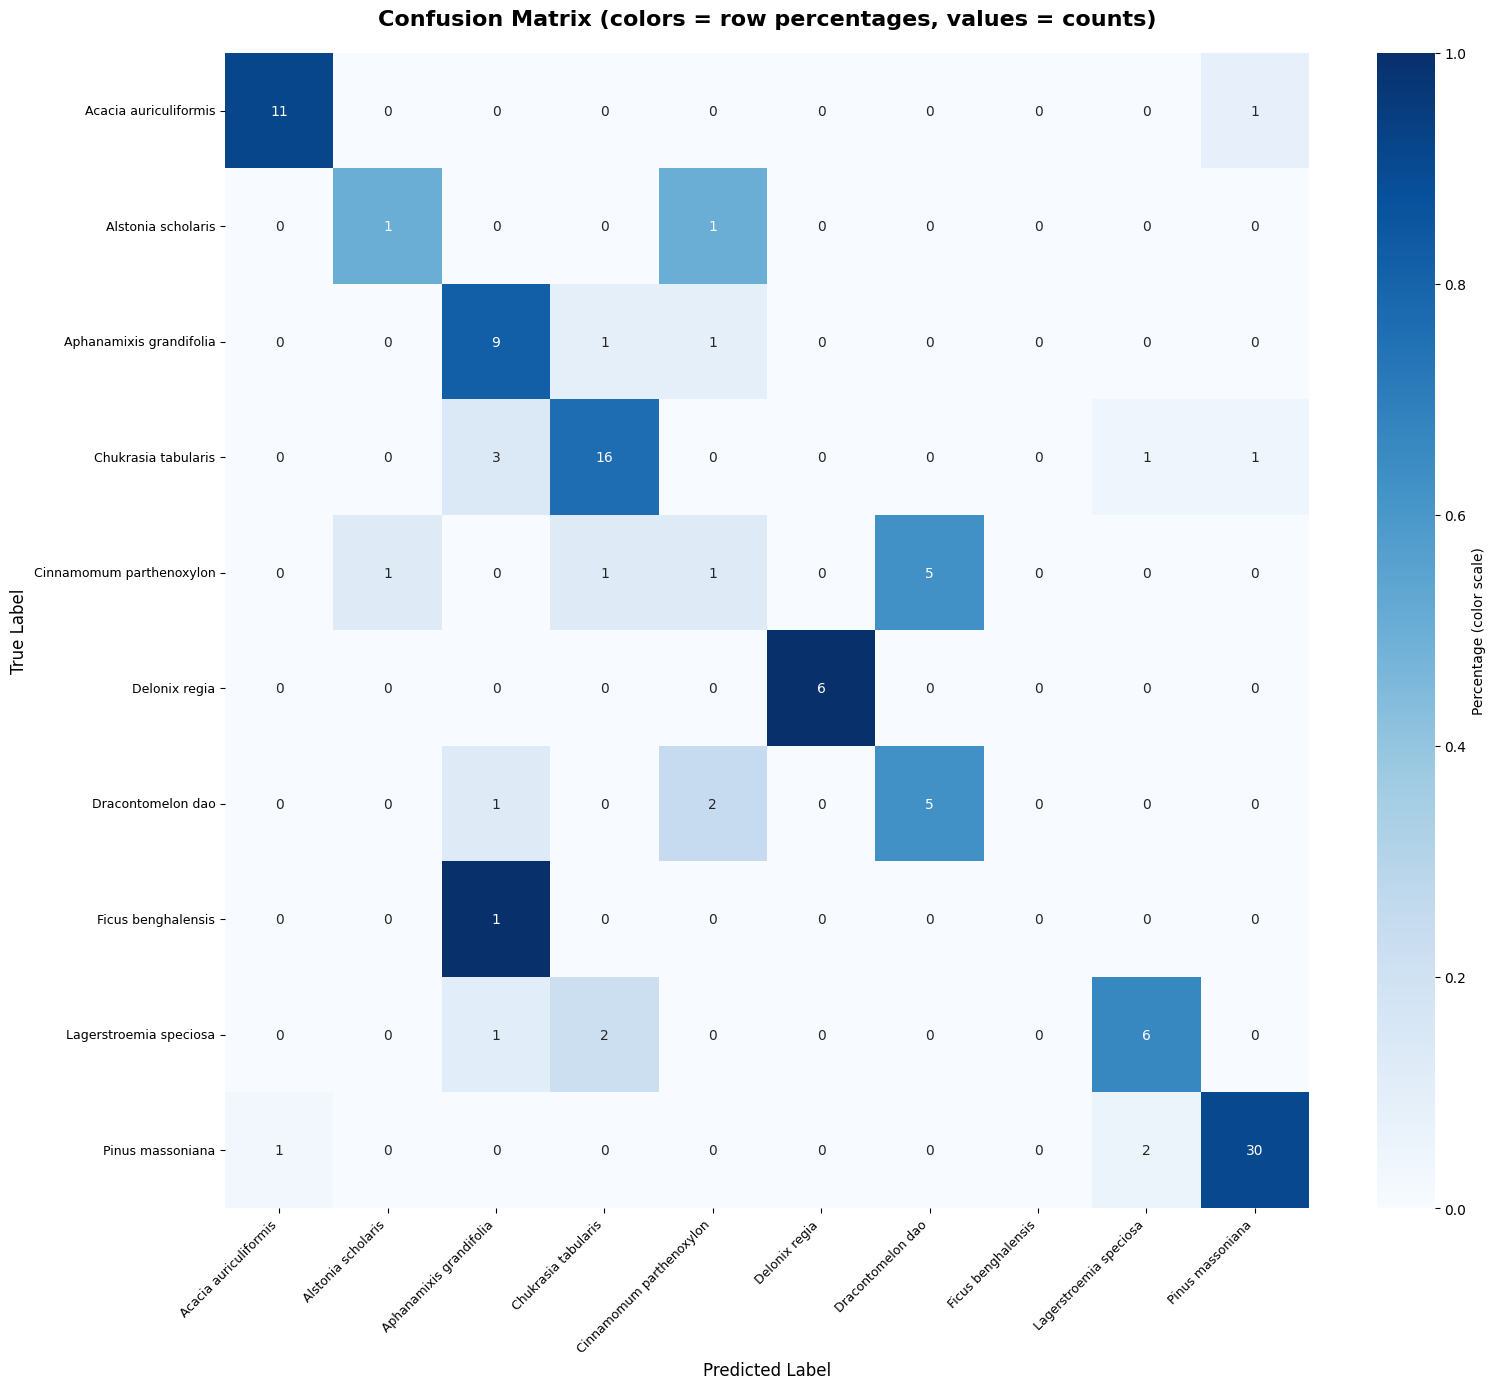

📊 Confusion matrix saved to test_confusion_matrix_global.png


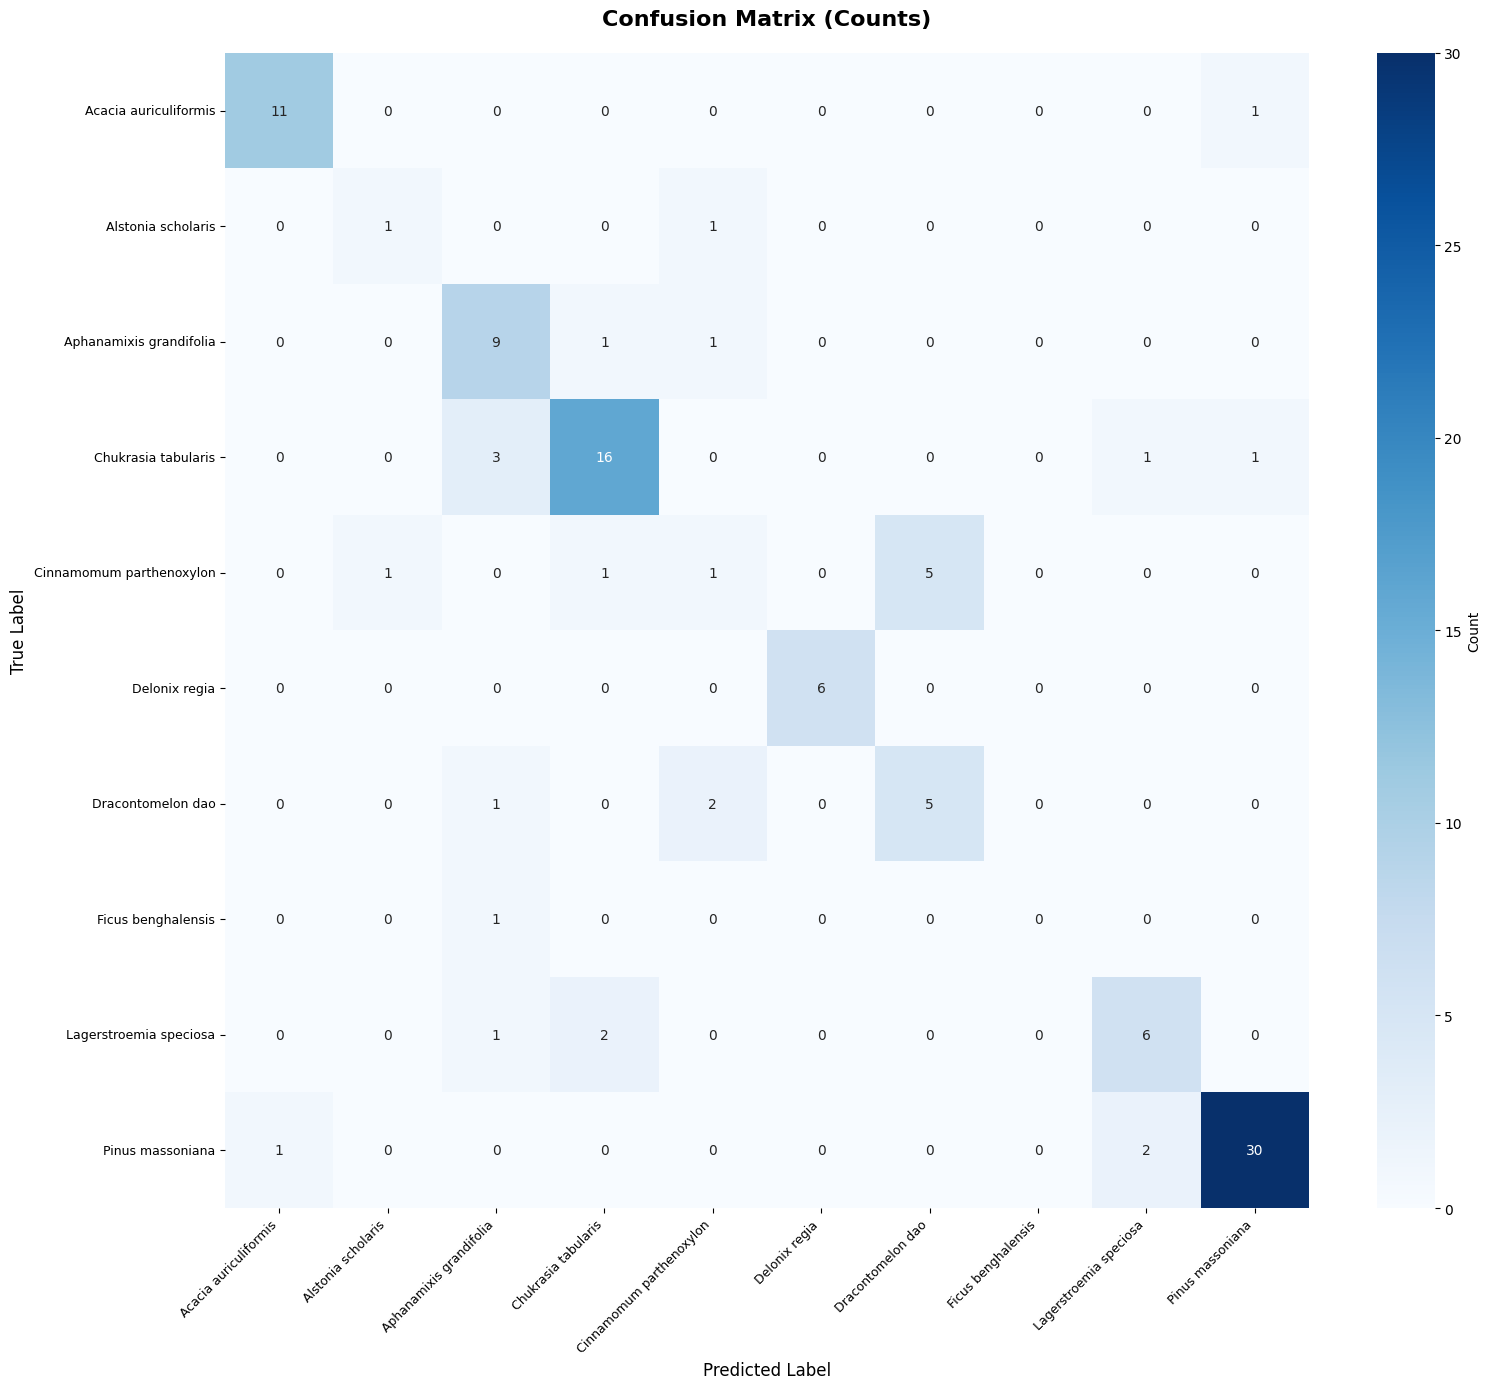


🎉 FINAL TEST RESULTS:
   Accuracy: 76.58%
   Precision: 61.21%
   Recall: 63.23%
   F1-Score: 61.89%


{'test_accuracy': 76.57657657657657,
 'test_precision': 61.20833333333333,
 'test_recall': 63.22510822510823,
 'test_f1_score': 61.886074629977074,
 'per_class_metrics': {'Acacia auriculiformis': {'precision': 91.66666666666666,
   'recall': 91.66666666666666,
   'f1_score': 91.66666666666666,
   'support': 12},
  'Alstonia scholaris': {'precision': 50.0,
   'recall': 50.0,
   'f1_score': 50.0,
   'support': 2},
  'Aphanamixis grandifolia': {'precision': 60.0,
   'recall': 81.81818181818183,
   'f1_score': 69.23076923076923,
   'support': 11},
  'Chukrasia tabularis': {'precision': 80.0,
   'recall': 76.19047619047619,
   'f1_score': 78.04878048780488,
   'support': 21},
  'Cinnamomum parthenoxylon': {'precision': 20.0,
   'recall': 12.5,
   'f1_score': 15.384615384615385,
   'support': 8},
  'Delonix regia': {'precision': 100.0,
   'recall': 100.0,
   'f1_score': 100.0,
   'support': 6},
  'Dracontomelon dao': {'precision': 50.0,
   'recall': 62.5,
   'f1_score': 55.55555555555556,
  

In [51]:
TEST_DIR = "/content/VNUF-24082024-299/test"

# 2. Cell này dùng để Test riêng biệt
print("Running Testing Step...")

# Sử dụng model đã lưu từ lần train trước
model_path = f"NONE_VNUF154_best_{DEFAULT_CONFIG['model_name']}.pth"
# model_path = "/content/drive/MyDrive/cvbmc/model_chkpoint/NONE_VNUF154_best_xception.pth"

# Chạy test
run_testing(model_path)

Running Testing Step...
🚀 Starting Testing Process using model: NONE_VNUF154_best_xception.pth...
Number of classes: 10


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Using Focal Loss with per-class alpha weights (gamma=2.0)
Model: xception
Device: cuda
Loading model from NONE_VNUF154_best_xception.pth

🧪 EVALUATING ON TEST SET


Testing: 100%|██████████| 2/2 [00:00<00:00,  3.43it/s, Loss=3.5588, Acc=30.61%]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c


🎯 DETAILED TEST RESULTS
Overall Accuracy: 30.61%
Overall Precision (Macro): 37.22%
Overall Recall (Macro): 24.61%
Overall F1-Score (Macro): 22.77%

📊 PER-CLASS METRICS:
----------------------------------------------------------------------
Class                Precision    Recall       F1-Score     Support   
----------------------------------------------------------------------
Acacia auriculiformis 100.00     % 21.74      % 35.71      % 23        
Alstonia scholaris   0.00       % 0.00       % 0.00       % 1         
Aphanamixis grandifolia 33.33      % 94.12      % 49.23      % 17        
Chukrasia tabularis  5.56       % 14.29      % 8.00       % 7         
Cinnamomum parthenoxylon 50.00      % 16.67      % 25.00      % 12        
Delonix regia        100.00     % 50.00      % 66.67      % 2         
Dracontomelon dao    16.67      % 37.50      % 23.08      % 8         
Ficus benghalensis   0.00       % 0.00       % 0.00       % 3         
Lagerstroemia speciosa 0.00       % 0.00 

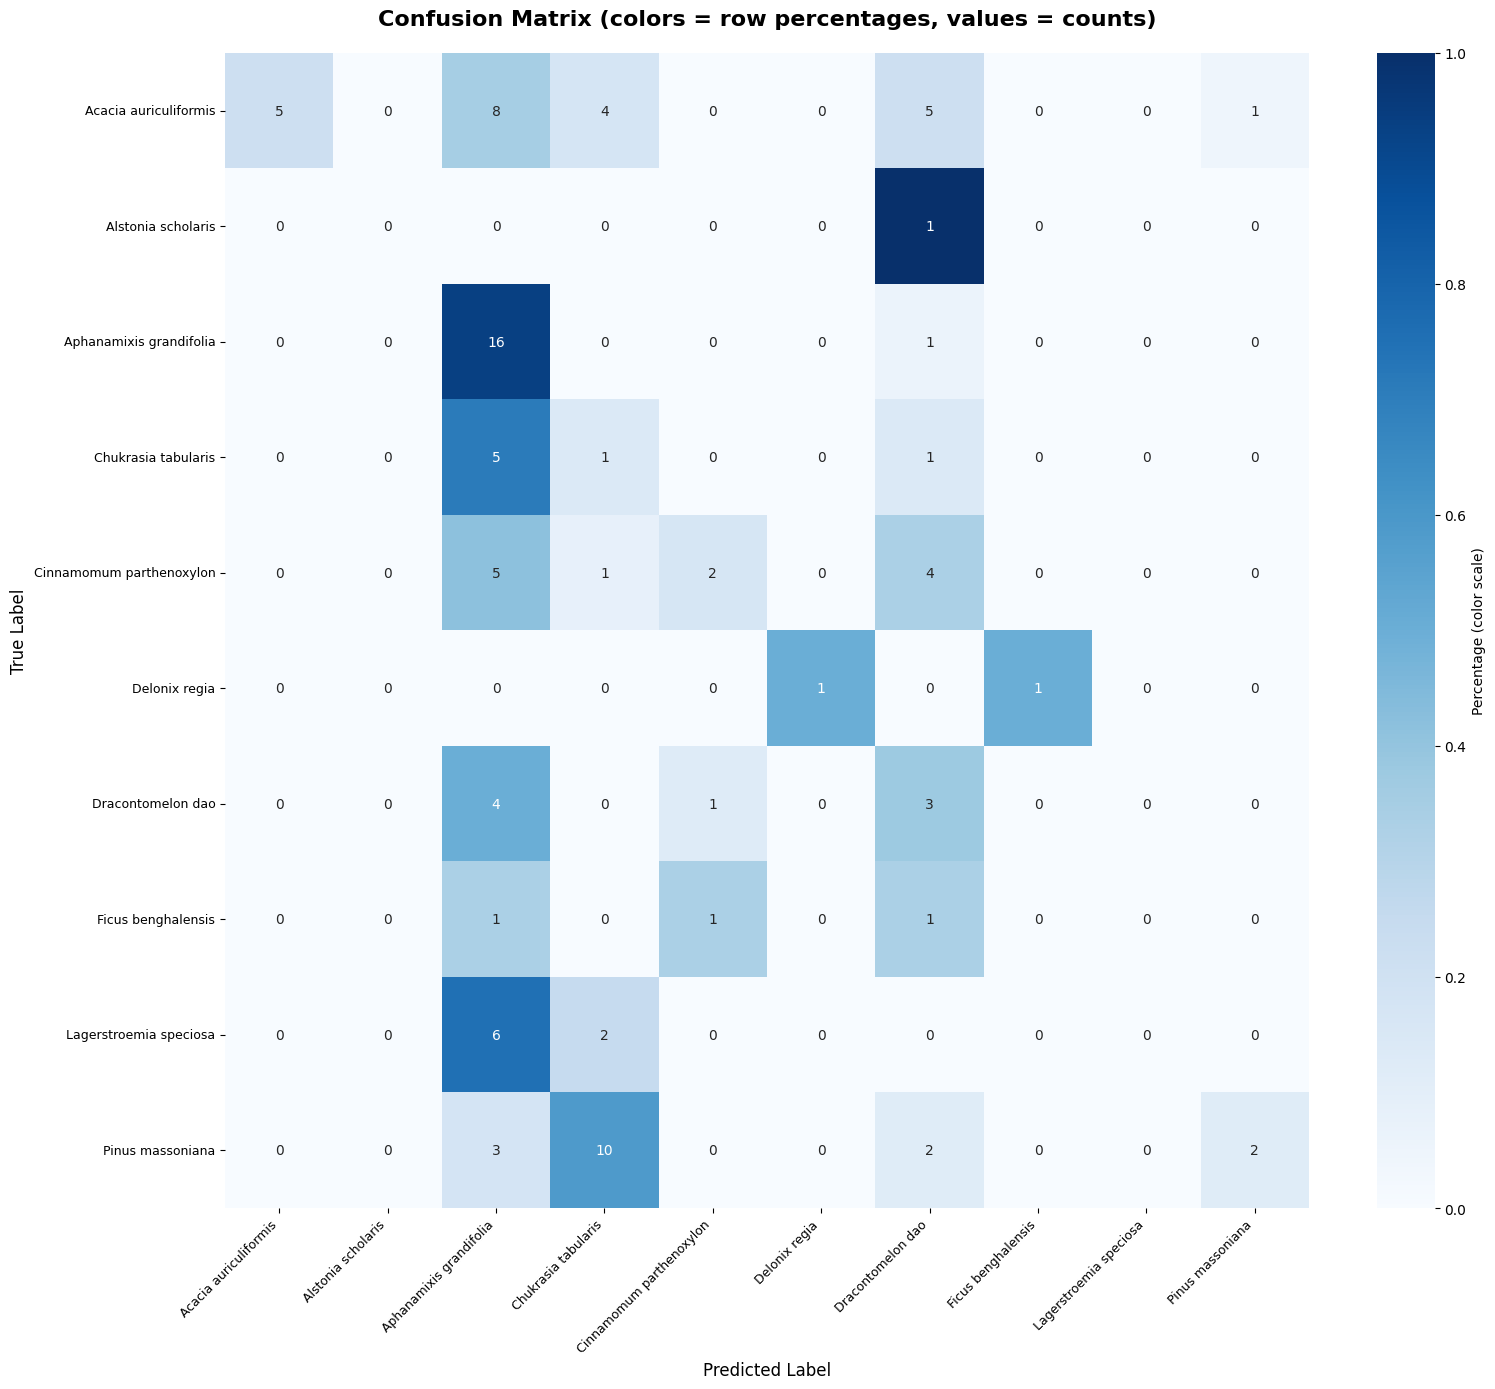

📊 Confusion matrix saved to test_confusion_matrix_global.png


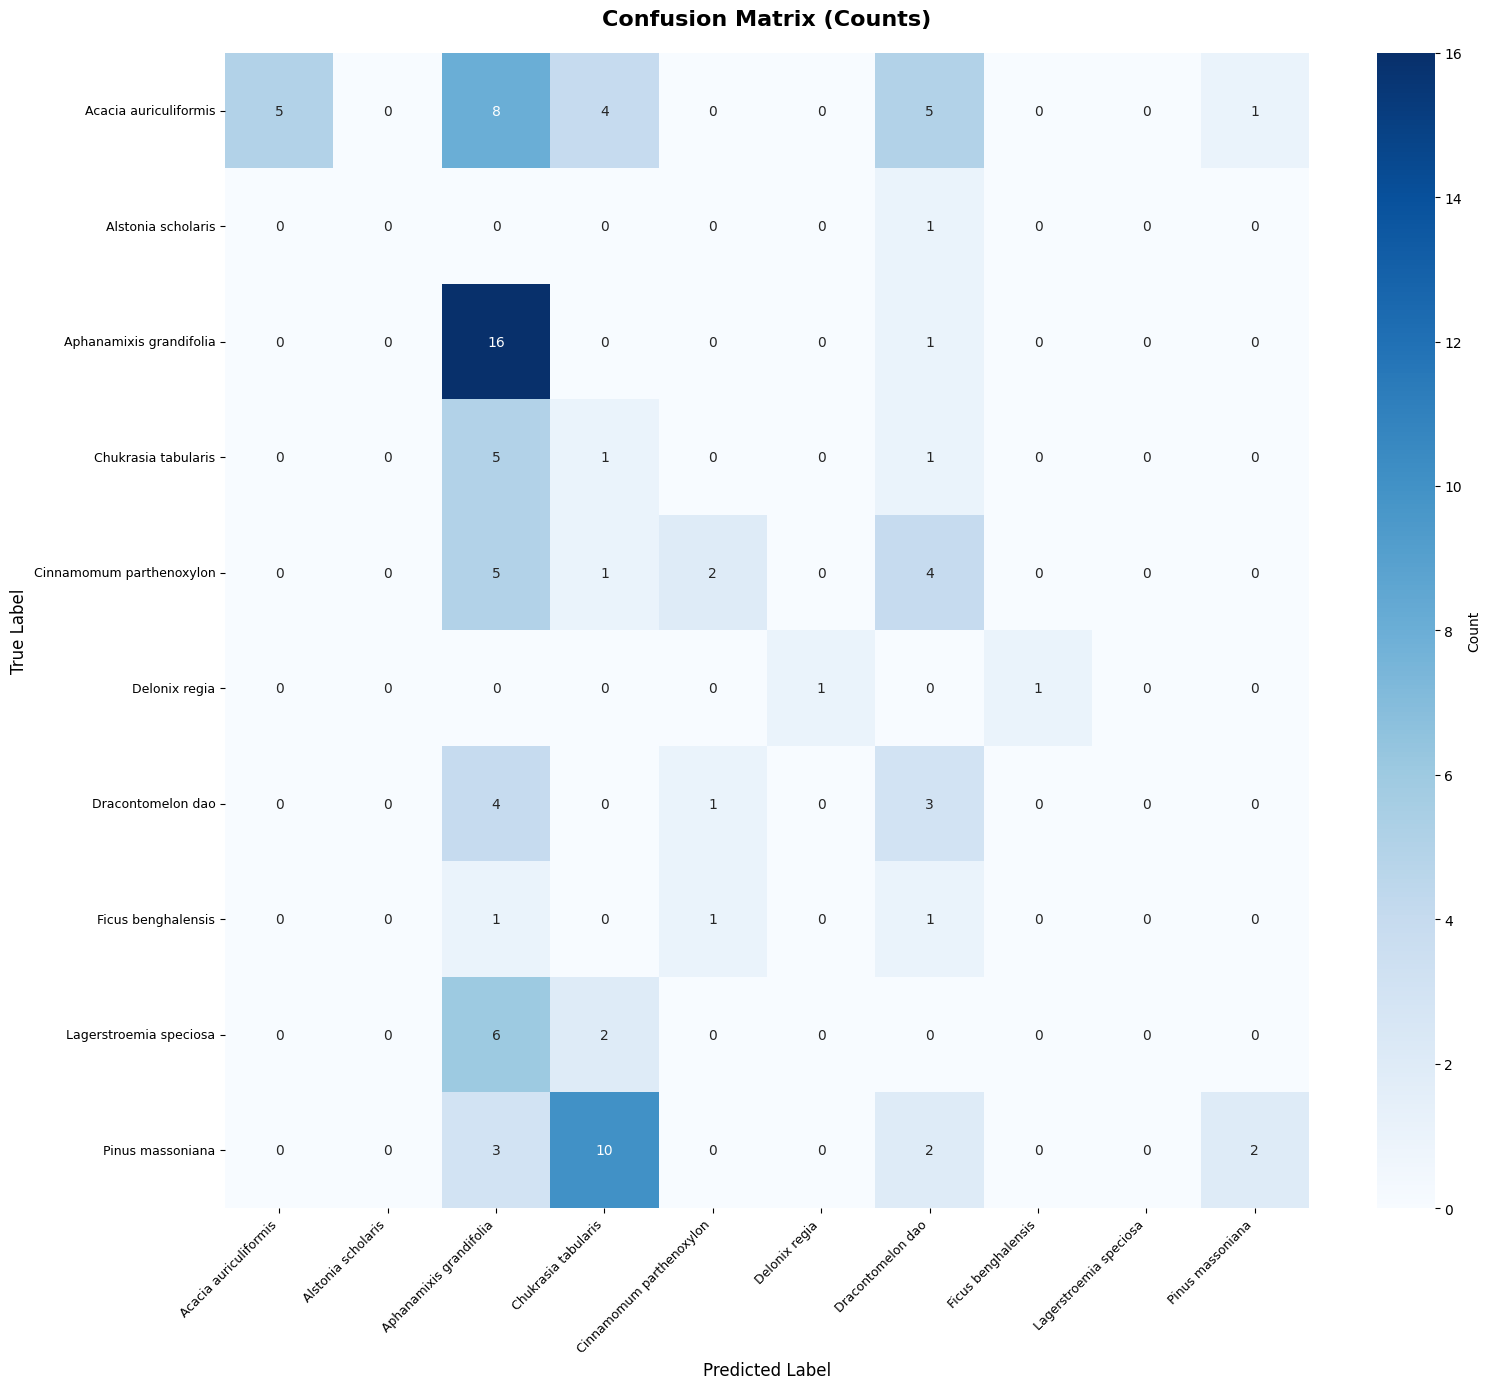


🎉 FINAL TEST RESULTS:
   Accuracy: 30.61%
   Precision: 37.22%
   Recall: 24.61%
   F1-Score: 22.77%


{'test_accuracy': 30.612244897959183,
 'test_precision': 37.222222222222214,
 'test_recall': 24.607386432834005,
 'test_f1_score': 22.76886446886447,
 'per_class_metrics': {'Acacia auriculiformis': {'precision': 100.0,
   'recall': 21.73913043478261,
   'f1_score': 35.714285714285715,
   'support': 23},
  'Alstonia scholaris': {'precision': 0.0,
   'recall': 0.0,
   'f1_score': 0.0,
   'support': 1},
  'Aphanamixis grandifolia': {'precision': 33.33333333333333,
   'recall': 94.11764705882352,
   'f1_score': 49.23076923076923,
   'support': 17},
  'Chukrasia tabularis': {'precision': 5.555555555555555,
   'recall': 14.285714285714285,
   'f1_score': 8.0,
   'support': 7},
  'Cinnamomum parthenoxylon': {'precision': 50.0,
   'recall': 16.666666666666664,
   'f1_score': 25.0,
   'support': 12},
  'Delonix regia': {'precision': 100.0,
   'recall': 50.0,
   'f1_score': 66.66666666666666,
   'support': 2},
  'Dracontomelon dao': {'precision': 16.666666666666664,
   'recall': 37.5,
   'f1_sco

In [52]:
TEST_DIR = "/content/VNUF-10082024-234/test"

# 2. Cell này dùng để Test riêng biệt
print("Running Testing Step...")

# Sử dụng model đã lưu từ lần train trước
model_path = f"NONE_VNUF154_best_{DEFAULT_CONFIG['model_name']}.pth"
# model_path = "/content/drive/MyDrive/cvbmc/model_chkpoint/NONE_VNUF154_best_xception.pth"

# Chạy test
run_testing(model_path)

### Tạo folder mới và trộn dữ liệu

In [ ]:
import os
import shutil

# Define base paths for the source dataset
SOURCE_BASE_DIR = "/content/VNUF-10082024-234"
SOURCE_TRAIN_DIR = os.path.join(SOURCE_BASE_DIR, "train")
SOURCE_VAL_DIR = os.path.join(SOURCE_BASE_DIR, "val")
SOURCE_TEST_DIR = os.path.join(SOURCE_BASE_DIR, "test")

# Define the destination path for the mixed dataset
DEST_MIX_DIR = "/content/VNUF-10082024-234-mix"

print(f"Source dataset base directory: {SOURCE_BASE_DIR}")
print(f"Destination mixed directory: {DEST_MIX_DIR}")

Source dataset base directory: /content/VNUF-10082024-234
Destination mixed directory: /content/VNUF-10082024-234-mix


In [ ]:
# Create the destination mixed directory if it doesn't exist
os.makedirs(DEST_MIX_DIR, exist_ok=True)
print(f"Created or ensured existence of: {DEST_MIX_DIR}")

# List of source directories to combine
source_dirs = [SOURCE_TRAIN_DIR, SOURCE_VAL_DIR, SOURCE_TEST_DIR]

# Iterate through each source directory (train, val, test)
for src_root_dir in source_dirs:
    if not os.path.exists(src_root_dir):
        print(f"Warning: Source directory not found: {src_root_dir}. Skipping.")
        continue

    print(f"\nProcessing images from: {src_root_dir}")
    # Iterate through each class subfolder in the current source directory
    for class_name in os.listdir(src_root_dir):
        src_class_dir = os.path.join(src_root_dir, class_name)
        dest_class_dir = os.path.join(DEST_MIX_DIR, class_name)

        # Create the corresponding class subfolder in the destination mixed directory
        os.makedirs(dest_class_dir, exist_ok=True)

        # Copy all image files from the source class directory to the destination class directory
        for filename in os.listdir(src_class_dir):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
                src_file_path = os.path.join(src_class_dir, filename)
                dest_file_path = os.path.join(dest_class_dir, filename)

                # Handle potential duplicate filenames by appending a suffix
                counter = 1
                original_filename_no_ext, ext = os.path.splitext(filename)
                while os.path.exists(dest_file_path):
                    dest_file_path = os.path.join(dest_class_dir, f"{original_filename_no_ext}_{counter}{ext}")
                    counter += 1

                shutil.copy(src_file_path, dest_file_path)

        print(f"  Copied images for class '{class_name}' to {dest_class_dir}")

print("\n✨ Data mixing complete. All images are now in the VNUF-24082024-299-mix folder.")

Created or ensured existence of: /content/VNUF-10082024-234-mix

Processing images from: /content/VNUF-10082024-234/train
  Copied images for class 'Alstonia scholaris' to /content/VNUF-10082024-234-mix/Alstonia scholaris
  Copied images for class 'Aphanamixis grandifolia' to /content/VNUF-10082024-234-mix/Aphanamixis grandifolia
  Copied images for class 'Dracontomelon dao' to /content/VNUF-10082024-234-mix/Dracontomelon dao
  Copied images for class 'Ficus benghalensis' to /content/VNUF-10082024-234-mix/Ficus benghalensis
  Copied images for class 'Chukrasia tabularis' to /content/VNUF-10082024-234-mix/Chukrasia tabularis
  Copied images for class 'Cinnamomum parthenoxylon' to /content/VNUF-10082024-234-mix/Cinnamomum parthenoxylon
  Copied images for class 'Lagerstroemia speciosa' to /content/VNUF-10082024-234-mix/Lagerstroemia speciosa
  Copied images for class 'Acacia auriculiformis' to /content/VNUF-10082024-234-mix/Acacia auriculiformis
  Copied images for class 'Delonix regia' 

Running Testing Step...
🚀 Starting Testing Process using model: NONE_VNUF154_best_xception.pth...
Number of classes: 10


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Using Focal Loss with per-class alpha weights (gamma=2.0)
Model: xception
Device: cuda
Loading model from NONE_VNUF154_best_xception.pth

🧪 EVALUATING ON TEST SET


Testing: 100%|██████████| 26/26 [00:02<00:00, 12.19it/s, Loss=0.2394, Acc=47.07%]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric


🎯 DETAILED TEST RESULTS
Overall Accuracy: 47.07%
Overall Precision (Macro): 44.93%
Overall Recall (Macro): 32.54%
Overall F1-Score (Macro): 29.43%

📊 PER-CLASS METRICS:
----------------------------------------------------------------------
Class                Precision    Recall       F1-Score     Support   
----------------------------------------------------------------------
Acacia auriculiformis 98.88      % 64.48      % 78.06      % 411       
Alstonia scholaris   0.00       % 0.00       % 0.00       % 9         
Aphanamixis grandifolia 35.27      % 90.10      % 50.70      % 202       
Chukrasia tabularis  26.17      % 56.12      % 35.70      % 139       
Cinnamomum parthenoxylon 63.52      % 37.69      % 47.31      % 268       
Delonix regia        100.00     % 3.70       % 7.14       % 135       
Dracontomelon dao    25.37      % 45.39      % 32.55      % 152       
Ficus benghalensis   0.00       % 0.00       % 0.00       % 17        
Lagerstroemia speciosa 7.69       % 5.00 

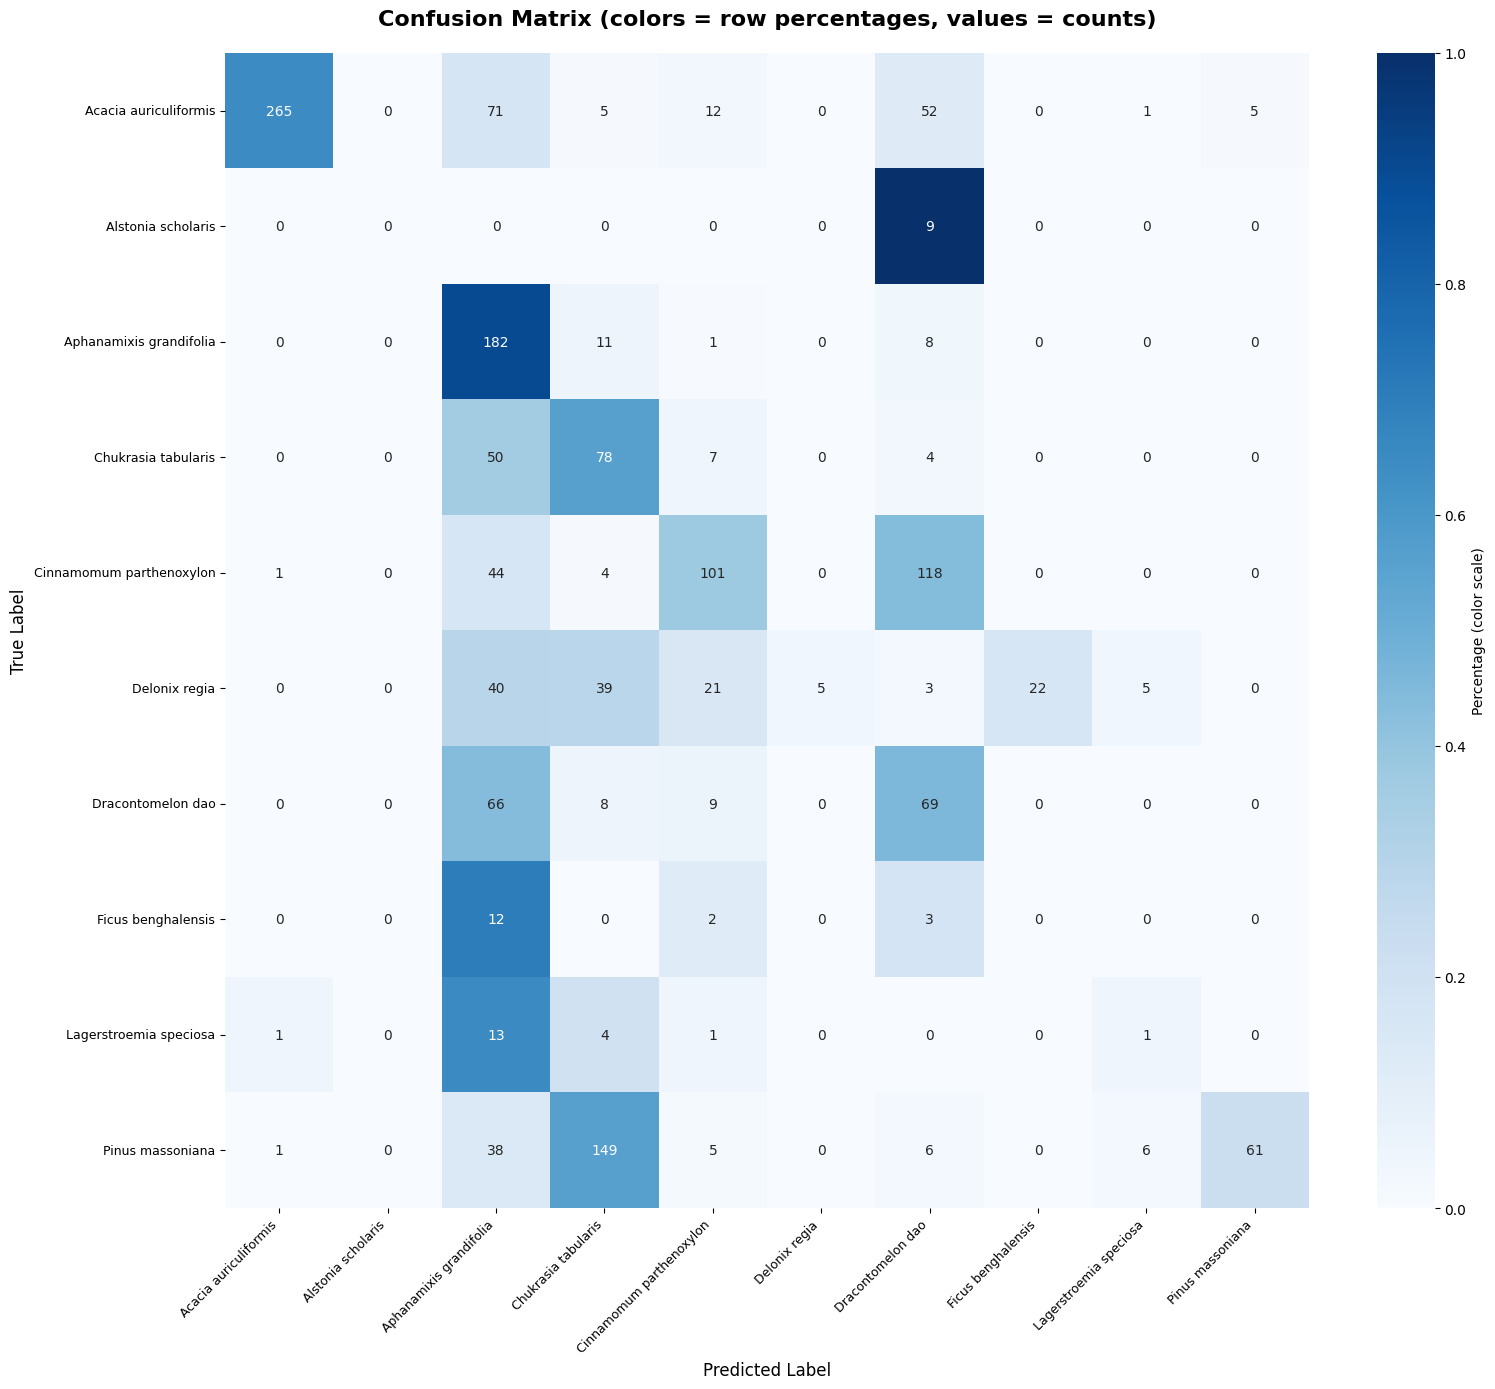

📊 Confusion matrix saved to test_confusion_matrix_global.png


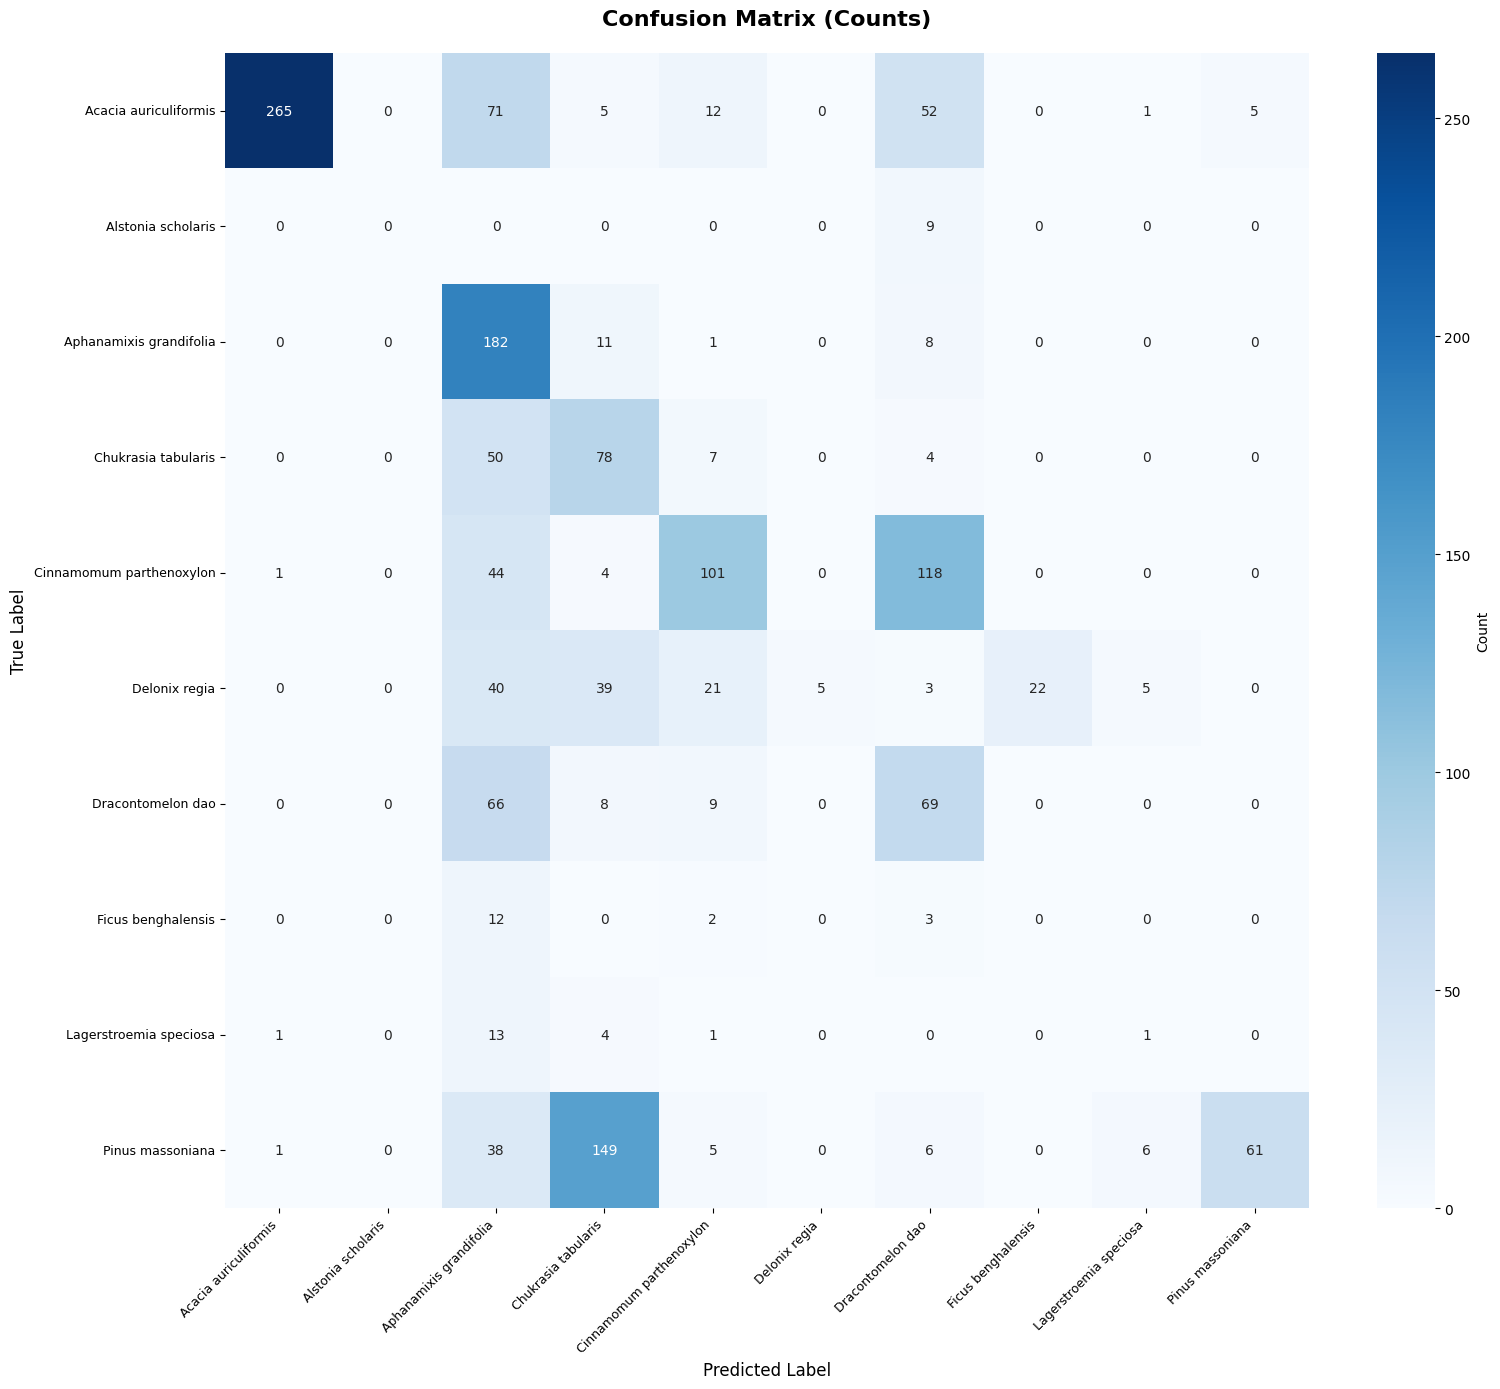


🎉 FINAL TEST RESULTS:
   Accuracy: 47.07%
   Precision: 44.93%
   Recall: 32.54%
   F1-Score: 29.43%


{'test_accuracy': 47.06609017912292,
 'test_precision': 44.933262124266804,
 'test_recall': 32.54083419964838,
 'test_f1_score': 29.425469652309673,
 'per_class_metrics': {'Acacia auriculiformis': {'precision': 98.88059701492537,
   'recall': 64.47688564476886,
   'f1_score': 78.0559646539028,
   'support': 411},
  'Alstonia scholaris': {'precision': 0.0,
   'recall': 0.0,
   'f1_score': 0.0,
   'support': 9},
  'Aphanamixis grandifolia': {'precision': 35.27131782945737,
   'recall': 90.0990099009901,
   'f1_score': 50.69637883008357,
   'support': 202},
  'Chukrasia tabularis': {'precision': 26.174496644295303,
   'recall': 56.11510791366906,
   'f1_score': 35.6979405034325,
   'support': 139},
  'Cinnamomum parthenoxylon': {'precision': 63.52201257861635,
   'recall': 37.6865671641791,
   'f1_score': 47.306791569086656,
   'support': 268},
  'Delonix regia': {'precision': 100.0,
   'recall': 3.7037037037037033,
   'f1_score': 7.142857142857142,
   'support': 135},
  'Dracontomelon da

In [53]:
TEST_DIR = "/content/VNUF-10082024-234-mix"

# 2. Cell này dùng để Test riêng biệt
print("Running Testing Step...")

# Sử dụng model đã lưu từ lần train trước
# model_path = f"NONE_VNUF154_best_{DEFAULT_CONFIG['model_name']}.pth" model_path = "/content/drive/MyDrive/cvbmc/model_chkpoint/NONE_VNUF154_best_xception.pth"

# Chạy test
run_testing(model_path)

In [ ]:
# !mkdir /content/drive/MyDrive/cvbmc/model_chkpoint/1004

In [55]:
!cp -r "/content/NONE_VNUF154_best_xception.pth" "/content/drive/MyDrive/cvbmc/model_chkpoint/1004"